### Installs and Imports

In [220]:
%pip install -q pandas
%pip install -q statsbombpy
%pip install -q networkx
%pip install -q matplotlib
%pip install -q jinja2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [170]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import warnings
from statsbombpy.api_client import NoAuthWarning

# Filter out the specific StatsBomb NoAuthWarning
warnings.simplefilter("ignore", NoAuthWarning)

# Now import/run statsbombpy cleanly without the warning
from statsbombpy import sb

# Display configuration for clean output inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Competition Extraction

In [198]:
# Retrieve the competitions DataFrame
competitions_df = sb.competitions()
print(f"Total Competitions Returned: {len(competitions_df)}")

# Filter the DataFrame for WSL 2023/2024
target_filter = (competitions_df['competition_id'] == 37) & (competitions_df['season_id'] == 281)
wsl_competition = competitions_df[target_filter].to_dict(orient='records')[0]

# Print the extracted row
print("\nExtracted Competition Payload:")
print(wsl_competition)

Total Competitions Returned: 80

Extracted Competition Payload:
{'competition_id': 37, 'season_id': 281, 'country_name': 'England', 'competition_name': "FA Women's Super League", 'competition_gender': 'female', 'competition_youth': False, 'competition_international': False, 'season_name': '2023/2024', 'match_updated': '2026-04-11T13:05:10.794831', 'match_updated_360': None, 'match_available_360': None, 'match_available': '2026-04-11T13:05:10.794831'}


### Helper Functions

In [390]:
def scale_coord(val, axis='x'):
    """
    Scales StatsBomb pitch coordinates (120x80) to a standard percentage scale (0-100).
    """
    if val is None or pd.isna(val):
        return val
        
    axis = str(axis).lower()
    if axis == 'x':
        return (val / 120.0) * 100.0
    elif axis == 'y':
        return (val / 80.0) * 100.0
    else:
        raise ValueError("Axis must be 'x' or 'y'.")

In [3]:
def parse_minute(val, default_val=0):
    """Safely extracts the minute integer from a StatsBomb 'from' or 'to' timestamp."""
    if val is None:
        return default_val
    if isinstance(val, (int, float)):
        return int(val)
    if isinstance(val, str) and ':' in val:
        return int(val.split(':')[0])  # Take 'MM' from 'MM:SS'
    try:
        return int(val)
    except ValueError:
        return default_val

In [4]:
def extract_11_players(player_list):
    """Used to turn a teams match roster into an 11 player list"""
    sorted_players = sorted(player_list, key=lambda x: x['Minutes Played'], reverse=True)
    top_11_players = sorted_players[:11]
    return top_11_players

### Match Extractions

Here is the current implementation of the code. What I have done is code an implementation which will extract 2 lists for every match. The lists contain a match_id, team_name, and a list containing the active players from the match. This player listed contains all players that entered the field but it contains a minutes players field so later on I can filter down to the 11. The purpose of this data structure is to give me a list that I can loop through. Each list represents the basis of a network, i.e. the fields can be used to extract the passes from events and the player level info establish the nodes

In [199]:
# Fetch WSL 2023/2024 Matches
COMPETITION_ID = 37
SEASON_ID = 281

matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"League contains {len(matches_df)} matches.")
match_records = []

for idx, match in matches_df.iterrows():
    m_id = match['match_id']
    events_df = sb.events(match_id=m_id)
    max_minute = int(events_df['minute'].max())
    lineups = sb.lineups(match_id=m_id)
    
    for team in lineups:
        roster = len(lineups[team]['player_id'].tolist())
        player_list = []

        # Extract Player Level Data
        for player_index in range(0,roster):
            if not lineups[team]['positions'][player_index]:
                pass
            else:
                start = lineups[team]['positions'][player_index][0]
                end = lineups[team]['positions'][player_index][-1]
                pos = start['position']
                # Started
                if start['start_reason'] == 'Starting XI':
                    started = 1
                    _from = 0
                    if start['end_reason'] == 'Final Whistle':
                        full_match = 1
                        to = max_minute
                    else:
                        if end['end_reason'] == 'Final Whistle':
                            full_match = 1
                            to = max_minute
                        else:
                            full_match = 0
                            to = parse_minute(end.get('to'), default_val=max_minute)
                # Didnt Start
                else: 
                    started = 0
                    _from = parse_minute(start.get('from'), default_val=max_minute)
                    if end['to']: # Didnt start and Didnt finish
                        to = parse_minute(end.get('to'), default_val=max_minute)
                    else:
                        to = max_minute
                    full_match = 0
                
                # player index
                pid = lineups[team]['player_id'].tolist()[player_index]
                pn = lineups[team]['player_name'].tolist()[player_index]

                player_dict = {
                    "Player Name": pn,
                    "Player ID": pid,
                    "Position": pos,
                    # "Started": started,
                    # "Full Match": full_match,
                    "Starting Minute": _from,
                    "Ending Minute": to,
                    "Minutes Played": (to-_from),
                }

                player_list.append(player_dict)

        match_records.append([idx, m_id, team, player_list])

        # TOOD: we need to extract starting formation here

League contains 132 matches.


In [200]:
print("Match Index", match_records[0][0])
print("Match ID", match_records[0][1])
print("Team Name", match_records[0][2])
print("Player List", match_records[0][3])

Match Index 0
Match ID 3913082
Team Name Brighton & Hove Albion WFC
Player List [{'Player Name': 'Maria Thorisdottir', 'Player ID': 4636, 'Position': 'Center Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'María Victoria Losada Gómez', 'Player ID': 10158, 'Position': 'Right Defensive Midfield', 'Starting Minute': 54, 'Ending Minute': 100, 'Minutes Played': 46}, {'Player Name': 'Tatiana Vanessa Ferreira Pinto', 'Player ID': 10167, 'Position': 'Left Midfield', 'Starting Minute': 95, 'Ending Minute': 100, 'Minutes Played': 5}, {'Player Name': 'Sophie Baggaley', 'Player ID': 16376, 'Position': 'Goalkeeper', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Pauline Bremer', 'Player ID': 20725, 'Position': 'Left Wing', 'Starting Minute': 0, 'Ending Minute': 95, 'Minutes Played': 95}, {'Player Name': 'Katie Robinson', 'Player ID': 21059, 'Position': 'Right Wing Back', 'Starting Minute': 0, 'Ending Minute': 68, 'Min

### Match Supplementation (Total Passes and 11 Players)

In [248]:
integrated_match_records = []

for match_data in match_records:
    match_index, m_id, team_name, player_list = match_data
    
    events = sb.events(match_id=m_id)

    # 1. Extract Starting Formation for the team
    starting_xi_events = events[
        (events["team"] == team_name) & (events["type"] == "Starting XI")
    ]

    if not starting_xi_events.empty:
        # Extract formation code (e.g., 433, 4231)
        if "tactics_formation" in starting_xi_events.columns:
            formation = starting_xi_events["tactics_formation"].iloc[0]
        else:
            # Fallback for dict-extracted tactics payload
            tactics_dict = starting_xi_events["tactics"].iloc[0]
            formation = (
                tactics_dict.get("formation")
                if isinstance(tactics_dict, dict)
                else "Unknown"
            )
    else:
        formation = "Unknown"

    # 2. Extract Successful Passes
    team_passes = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) # successful pass
    ]
    total_team_passes = len(team_passes)
    extracted_players_list = extract_11_players(player_list)
    
    # 3. Append Enriched Record (including formation)
    integrated_match_records.append([
        match_index,
        m_id,
        team_name,
        formation, 
        total_team_passes,
        player_list,
        extracted_players_list,
    ])

In [249]:
# ==============================================================================
# SAMPLE ENTRY VERIFICATION
# ==============================================================================
sample_entry = integrated_match_records[0]

print("\nSample Enriched Match Record:")
print(f"Match Index:  {sample_entry[0]}")
print(f"Match ID:     {sample_entry[1]}")
print(f"Team Name:    {sample_entry[2]}")
print(f"Formation:    {sample_entry[3]}")  # <--- Printed parameter
print(f"Total Passes: {sample_entry[4]}")
print(f"Roster Count: {len(sample_entry[5])} players")
print(f"Active Count: {len(sample_entry[6])} players")
print("Top 3 Players in Roster:")
for p in sample_entry[6][:3]:
    print(
        f"  • {p['Player Name']} ({p['Position']}) - {p['Minutes Played']} mins"
    )


Sample Enriched Match Record:
Match Index:  0
Match ID:     3913082
Team Name:    Brighton & Hove Albion WFC
Formation:    343
Total Passes: 204
Roster Count: 16 players
Active Count: 11 players
Top 3 Players in Roster:
  • Maria Thorisdottir (Center Back) - 100 mins
  • Sophie Baggaley (Goalkeeper) - 100 mins
  • Emma Nanny Charlotte Kullberg (Left Wing Back) - 100 mins


### High-Level Statistics (Match and Passes)

In [9]:
total_matches = len(match_records)/2
total_team_games = len(match_records)

# Extract total unique active players per team per match (before truncation)
players_used_per_game = [len(m[3]) for m in match_records]

mean_players_used = np.mean(players_used_per_game)
min_players_used = np.min(players_used_per_game)
max_players_used = np.max(players_used_per_game)

# Calculate total season passes across all matches
total_passes = 0
passes_per_team_game = []

for match_data in integrated_match_records:
    match_index, m_id, team_name, total_team_passes, player_list, extracted_players_list = match_data
    
    pass_count = total_team_passes
    total_passes += pass_count
    passes_per_team_game.append(pass_count)

mean_passes = np.mean(passes_per_team_game)
min_passes = np.min(passes_per_team_game)
max_passes = np.max(passes_per_team_game)

# ==============================================================================
# 3. PRINT GENERATED TABLE STATS
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)")
print("=" * 60)
print(f"Total Matches Analyzed:                 {total_matches}")
print(f"Total Team Match Networks:              {total_team_games}")
print(f"Total Completed Season Passes:          {total_passes:,}")
print(f"Mean Passes per Team per Match:         {mean_passes:.1f} (Range: {min_passes} - {max_passes})")
print(f"Mean Unique Players Used per Game:      {mean_players_used:.1f} (Range: {min_players_used} - {max_players_used})")
# print("=" * 60)


EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)
Total Matches Analyzed:                 132.0
Total Team Match Networks:              264
Total Completed Season Passes:          105,262
Mean Passes per Team per Match:         398.7 (Range: 120 - 847)
Mean Unique Players Used per Game:      15.1 (Range: 12 - 16)


### Highest Pass Match

In [10]:
# Returns a tuple: (list_index, max_record)
max_idx, highest_pass_match = max(
    enumerate(integrated_match_records), 
    key=lambda item: item[1][3]
)

print(f"Record Index: {max_idx}")
print(f"Match ID:     {highest_pass_match[1]}")
print(f"Team:         {highest_pass_match[2]}")
print(f"Passes:       {highest_pass_match[3]}")

Record Index: 60
Match ID:     3913160
Team:         Arsenal WFC
Passes:       847


### Network

PassMap Graph Successfully Built for Arsenal WFC (Match ID: 3913160)
• Nodes: 11 | Edges: 89 | Total Filtered Passes: 720


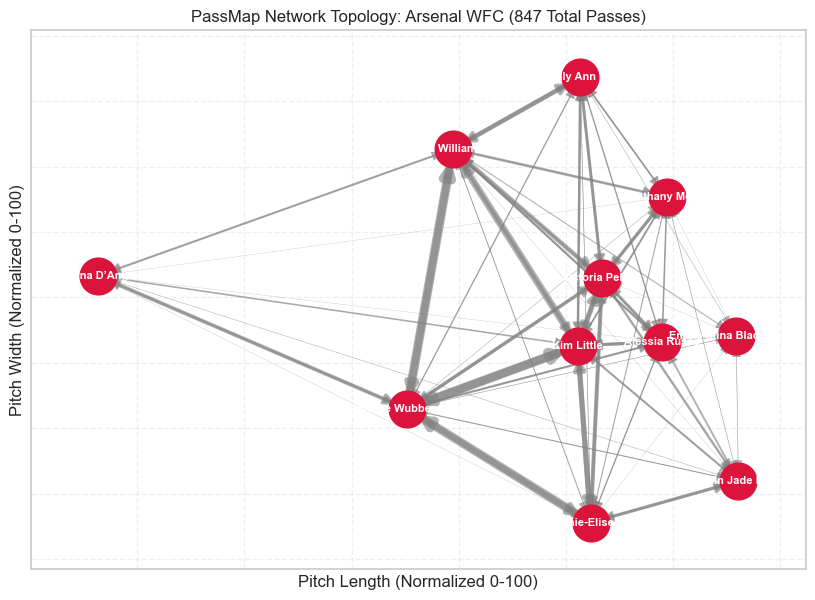

In [395]:
import networkx as nx
import matplotlib.pyplot as plt
from statsbombpy import sb

def build_passmap_network(match_record):
    """
    Constructs a weighted, directed NetworkX graph (nx.DiGraph) for a team passmap.
    
    Parameters:
        match_record (list): An entry from integrated_match_records in the format:
            [match_index, match_id, team_name, total_passes, player_list, top_11_players]
            
    Returns:
        G (nx.DiGraph): Directed graph where nodes are player names/IDs with spatial coordinates (x,y)
                        and edges represent completed pass counts between player pairs.
    """
    
    # Unpack record
    _, m_id, team_name, _, _, top_11_players = match_record
    
    # Extract Top-11 Player IDs and create a mapping for fast filtering
    top_11_ids = {p['Player ID'] for p in top_11_players}
    player_id_to_name = {p['Player ID']: p['Player Name'] for p in top_11_players}
    
    # Fetch event stream for the match
    events = sb.events(match_id=m_id)
    
    # Filter for successful passes belonging exclusively to the target team and Top-11 players
    passes_df = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) &
        (events['player_id'].isin(top_11_ids)) & 
        (events['pass_recipient_id'].isin(top_11_ids))
    ].copy()
    
    # Calculate Average Spatial Location (x, y) for each Top-11 player
    # This is the Node location in the pitch
    # Split StatsBomb 'location' list [x, y] into separate normalized coordinates (0-100 scale)
    passes_df['x'] = passes_df['location'].apply(lambda loc: (loc[0] / 120.0) * 100 if isinstance(loc, list) else None)
    passes_df['y'] = passes_df['location'].apply(lambda loc: (loc[1] / 80.0) * 100 if isinstance(loc, list) else None)
    avg_locations = passes_df.groupby('player_id')[['x', 'y']].mean().to_dict('index')
    
    # Initialize NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add Nodes with attributes (Name, Position, Average x,y)
    for p in top_11_players:
        p_id = p['Player ID']
        p_name = p['Player Name']
        p_pos = p['Position']
        loc = avg_locations.get(p_id, {'x': 50.0, 'y': 50.0})
        
        G.add_node(
            p_name,
            player_id=p_id,
            position=p_pos,
            pos=(loc['x'], loc['y']), # Position tuple for NetworkX layout
            x=loc['x'],
            y=loc['y']
        )
        
    # Aggregate Edges (Pass Volume between pairs)
    pass_counts = passes_df.groupby(['player_id', 'pass_recipient_id']).size().reset_index(name='weight')
    
    for _, row in pass_counts.iterrows():
        passer_name = player_id_to_name[row['player_id']]
        recipient_name = player_id_to_name[row['pass_recipient_id']]
        pass_volume = int(row['weight'])
        
        G.add_edge(passer_name, recipient_name, weight=pass_volume)
        
    print(f"PassMap Graph Successfully Built for {team_name} (Match ID: {m_id})")
    print(f"• Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Total Filtered Passes: {passes_df.shape[0]}")
    
    return G

# ==============================================================================
# EXECUTION & PLOTTING SHOWCASE
# ==============================================================================
# Build graph for the highest passing match (Record Index 60: Arsenal WFC with 847 passes)
G_arsenal = build_passmap_network(highest_pass_match)

# Plot network layout using NetworkX
plt.figure(figsize=(10, 7))

# Get node positions from attributes
pos = nx.get_node_attributes(G_arsenal, 'pos')
weights = [G_arsenal[u][v]['weight'] / 5.0 for u, v in G_arsenal.edges()] # Scale edge widths

# Draw nodes and edges
nx.draw_networkx_nodes(G_arsenal, pos, node_size=700, node_color='crimson')
nx.draw_networkx_edges(G_arsenal, pos, width=weights, edge_color='gray', alpha=0.6, arrowsize=15)
nx.draw_networkx_labels(G_arsenal, pos, font_size=8, font_color='white', font_weight='bold')

plt.title(f"PassMap Network Topology: Arsenal WFC ({highest_pass_match[3]} Total Passes)", fontsize=12)
plt.xlabel("Pitch Length (Normalized 0-100)")
plt.ylabel("Pitch Width (Normalized 0-100)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Pitch Plotting Function

In [106]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

# ==============================================================================
# 1. PURE MATPLOTLIB VERTICAL PITCH DRAWING (FIXED PATCH SYNTAX)
# ==============================================================================
def draw_vertical_pitch(ax=None, pitch_color='#f4f6f4', line_color='#708090'):
    """
    Draws a vertical football pitch on a 100x100 relative coordinate grid.
    
    Coordinates:
    - X (0 to 100): Horizontal Axis (Width - Touchline to Touchline)
    - Y (0 to 100): Vertical Axis (Length - Goal to Goal)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 11))
        
    ax.set_facecolor(pitch_color)
    
    # 1. Outer Boundary & Halfway Line
    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, edgecolor=line_color, lw=2))
    ax.plot([0, 100], [50, 50], color=line_color, lw=1.5)
    
    # Center circle & spot
    ax.add_patch(Circle((50, 50), 12, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 50), 0.8, fill=True, color=line_color))

    # 2. Defensive End (Bottom / GK Area)
    ax.add_patch(Rectangle((20, 0), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 0), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 12), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 18), width=20, height=20, angle=0, theta1=0, theta2=180, color=line_color, lw=1.5))

    # 3. Attacking End (Top)
    ax.add_patch(Rectangle((20, 82), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 94), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 88), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 82), width=20, height=20, angle=0, theta1=180, theta2=360, color=line_color, lw=1.5))

    # 4. Corner Arcs
    ax.add_patch(Arc((0, 0), width=6, height=6, angle=0, theta1=0, theta2=90, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 0), width=6, height=6, angle=0, theta1=90, theta2=180, color=line_color, lw=1.5))
    ax.add_patch(Arc((0, 100), width=6, height=6, angle=0, theta1=270, theta2=360, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 100), width=6, height=6, angle=0, theta1=180, theta2=270, color=line_color, lw=1.5))

    # 5. Axis Limits & Formatting
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax

<Axes: >

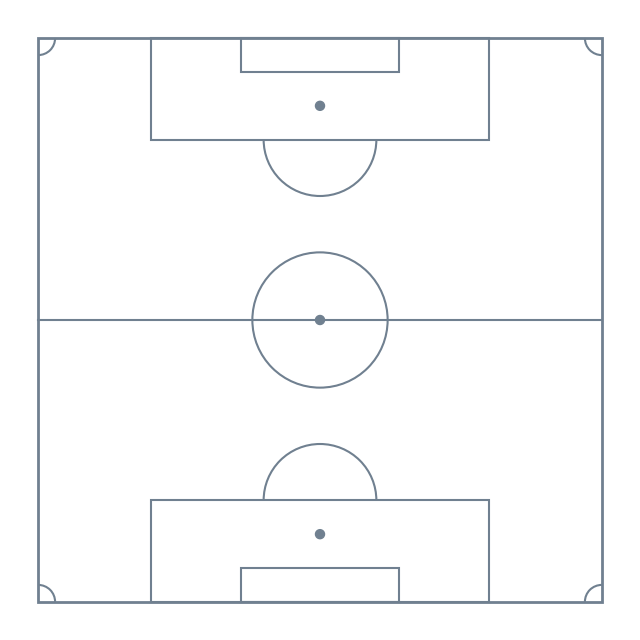

In [107]:
draw_vertical_pitch()

### Plotting Raw Passes

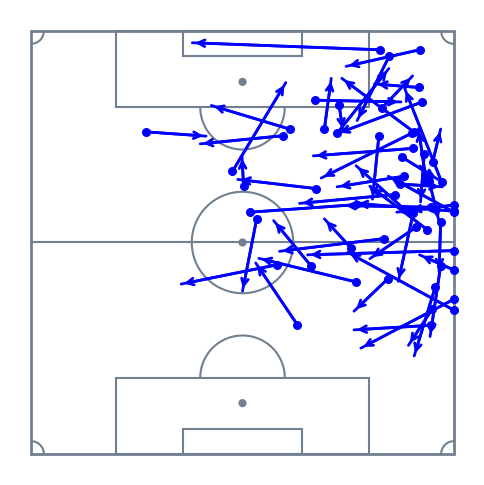

In [398]:
import matplotlib.pyplot as plt

# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(6, 9))

# 2. Draw the vertical pitch on the axis
draw_vertical_pitch(ax)

# 3. Sample pass data (adjust coordinates based on your function's grid, e.g., 100x100 or 105x68)
# Format: [x_start, y_start, x_end, y_end]
# passes = [
#     [120, 20, 50, 40],
# ]

events = sb.events(match_id=3913160)

# 2. Extract Successful Passes
_team_passes = events[
    (events['team'] == 'Arsenal WFC') & 
    (events['type'] == 'Pass') & 
    (events['pass_outcome'].isna()) & # successful pass
    (events['player'] == 'Emily Ann Fox')
]

passes = _team_passes[['location', 'pass_end_location']].apply(
    lambda row: [
        scale_coord(row['location'][1], axis='y'), scale_coord(row['location'][0], axis='x'), 
        scale_coord(row['pass_end_location'][1], axis='y'), scale_coord(row['pass_end_location'][0], axis='x')
    ], 
    axis=1
).tolist()

# 4. Plot passes over the pitch
for start_x, start_y, end_x, end_y in passes:
    # Plot line for the pass trajectory
    ax.plot([start_x, end_x], [start_y, end_y], color='blue', linewidth=2, zorder=3)
    
    # Plot start point
    ax.scatter(start_x, start_y, color='blue', s=30, zorder=4)
    
    # Optional: Add arrow to indicate direction
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(arrowstyle="->", color='blue', lw=2),
        zorder=3
    )

plt.show()

### PassMap Network on Pitch

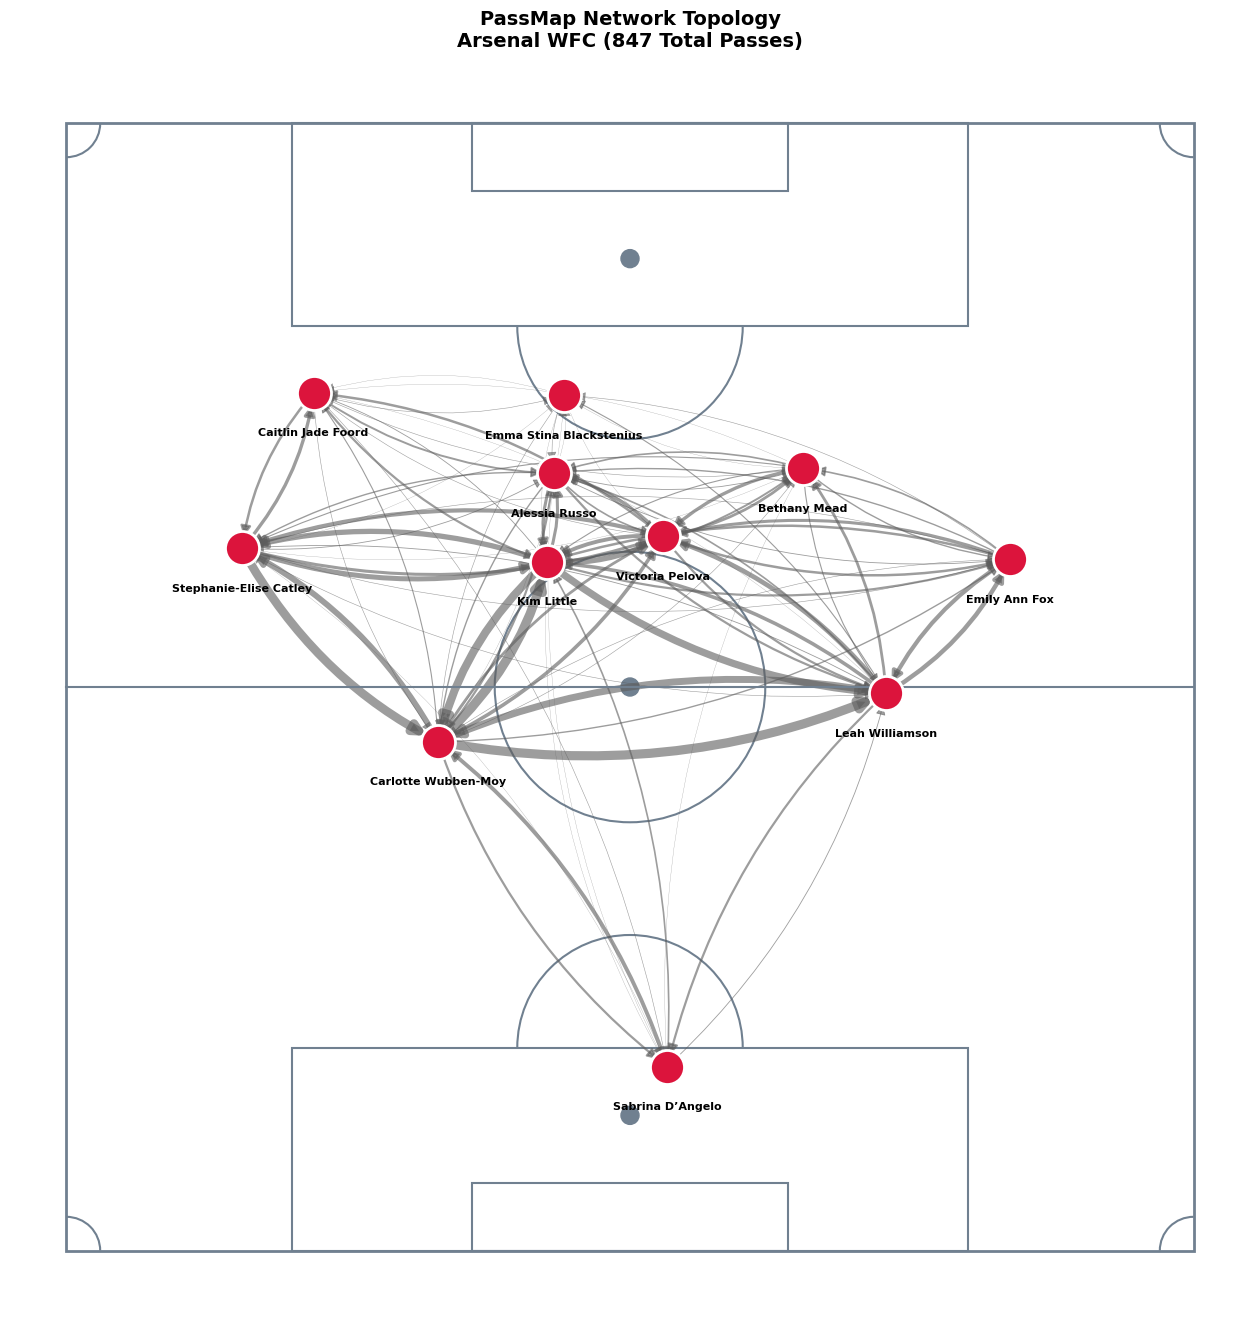

In [190]:
def plot_passmap_on_pitch(G, team_name, total_passes, metric_name=None, global_metric=None, node_scores=None, min_size=200, max_size=1200):
    """
    Overlays a NetworkX passmap graph onto the custom vertical pitch.
    """
    fig, ax = plt.subplots(figsize=(16, 22), facecolor='#ffffff')
    
    # 1. Draw the pitch background
    draw_vertical_pitch(ax=ax)
    
    # 2. Corrected Map Coordinates: (y, x) -> (width, length) (Vertical)
    pos_vertical = {node: (data['y'], data['x']) for node, data in G.nodes(data=True)}
    
    # 3. Create offset position for text labels
    label_pos = {node: (coords[0], coords[1] - 3.5) for node, coords in pos_vertical.items()}
    
    # 4. Scale edge weights for arrow width
    edges = G.edges()
    weights = [G[u][v]['weight'] / 5.0 for u, v in edges]

    # 5. Dynamic Node Sizing Logic
    if node_scores is not None:
        max_score = max(node_scores.values()) if node_scores.values() else 1.0
        # Map scores proportionally between min_size and max_size
        node_sizes = [
            min_size + (node_scores.get(node, 0.0) / (max_score if max_score > 0 else 1.0)) * (max_size - min_size)
            for node in G.nodes()
        ]
    else:
        node_sizes = 600  # Fallback fixed size


    # 6. Draw Edges with Curvature
    nx.draw_networkx_edges(
        G, pos_vertical, 
        ax=ax,
        edge_color='#5c5c5c',
        alpha=0.6,
        width=weights,
        arrowsize=15,
        connectionstyle="arc3,rad=0.15" 
    )
    
    # 7. Draw Player Nodes
    nx.draw_networkx_nodes(
        G, pos_vertical, 
        ax=ax,
        node_size=node_sizes, 
        node_color='crimson',
        edgecolors='white',
        linewidths=2
    )
    
    # 8. Draw Player Name Labels
    nx.draw_networkx_labels(
        G, label_pos, 
        ax=ax,
        font_size=8, 
        font_color='black', 
        font_weight='bold'
    )
    
    # 9. Title
    title_text = f"PassMap Network Topology\n{team_name} ({total_passes} Total Passes)"
    if metric_name is not None: title_text += f"\n{metric_name}: {global_metric}"
    plt.title(title_text, fontsize=14, fontweight='bold', color='black', pad=15)
    
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
plot_passmap_on_pitch(G_arsenal, highest_pass_match[2], highest_pass_match[3])

### Adjacency Matrix

In [146]:
import networkx as nx
import pandas as pd

# Convert to a labeled Pandas DataFrame
adj_df = nx.to_pandas_adjacency(G_arsenal, weight='weight', dtype=int)

print(adj_df)

                         Stephanie-Elise Catley  Sabrina D’Angelo  Emma Stina Blackstenius  Kim Little  Alessia Russo  Carlotte Wubben-Moy  Victoria Pelova  Leah Williamson  Emily Ann Fox  Caitlin Jade Foord  Bethany Mead
Stephanie-Elise Catley                        0                 0                        1          18              3                   31               11                2              2                  12             1
Sabrina D’Angelo                              1                 0                        0           6              0                   14                0                3              0                   2             0
Emma Stina Blackstenius                       0                 0                        0           1              2                    2                1                0              0                   1             1
Kim Little                                   19                 1                        0           0          

In [147]:
import networkx as nx

# Convert the weighted directed graph to a dense NumPy adjacency matrix
adj_matrix = nx.to_numpy_array(G_arsenal, weight='weight')

print(adj_matrix)

[[ 0.  0.  1. 18.  3. 31. 11.  2.  2. 12.  1.]
 [ 1.  0.  0.  6.  0. 14.  0.  3.  0.  2.  0.]
 [ 0.  0.  0.  1.  2.  2.  1.  0.  0.  1.  1.]
 [19.  1.  0.  0. 11. 29. 19. 26.  8.  3.  7.]
 [ 5.  1.  1. 11.  0.  5.  6.  8.  3.  0.  3.]
 [21.  8.  1. 33.  8.  0. 13. 33.  5.  4.  2.]
 [15.  0.  0. 14. 12. 10.  0.  8.  9.  9. 10.]
 [ 3.  8.  4. 13.  6. 25. 17.  0. 16.  1. 10.]
 [ 2.  0.  2.  9.  5.  2. 11. 15.  0.  0.  6.]
 [ 9.  0.  2.  8.  7.  2.  2.  0.  0.  0.  2.]
 [ 4.  1.  0.  4.  6.  0. 12.  4.  5.  1.  0.]]


### Degree Analysis

In [85]:
import numpy as np
import pandas as pd
import networkx as nx

def analyze_degree_and_heterogeneity(G, top_n_hubs=5):
    """
    Computes player-level degree/strength metrics, team-level Freeman Centralization,
    macro network heterogeneity statistics, and top hub rankings for a passing network.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        top_n_hubs (int): Number of top hubs to extract.
        
    Returns:
        metrics_df (pd.DataFrame): Player-level metric calculations.
        macro_metrics (dict): Team-level centralization and heterogeneity stats.
        hubs_df (pd.DataFrame): Rank-ordered table of top hub players.
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # -------------------------------------------------------------------------
    # 1. PLAYER-LEVEL DEGREE & STRENGTH METRICS
    # -------------------------------------------------------------------------
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())
    in_strength = dict(G.in_degree(weight='weight'))
    out_strength = dict(G.out_degree(weight='weight'))
    total_degree = dict(G.degree())
    
    player_metrics = []
    
    for node in nodes:
        k_in = in_degree[node]
        k_out = out_degree[node]
        s_in = in_strength[node]
        s_out = out_strength[node]
        s_tot = s_in + s_out
        
        # Directional Asymmetry
        net_flow = s_out - s_in
        pass_ratio = s_out / s_in if s_in > 0 else np.nan
            
        player_metrics.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "k_in (In-Degree)": k_in,
            "k_out (Out-Degree)": k_out,
            "s_in (Passes Rec.)": s_in,
            "s_out (Passes Comp.)": s_out,
            "Total Volume (s_tot)": s_tot,
            "Net Flow (Δs_i)": net_flow,
            "Pass Ratio (s_out / s_in)": round(pass_ratio, 2)
        })
        
    metrics_df = pd.DataFrame(player_metrics).set_index("Player")
    metrics_df = metrics_df.sort_values(by="Total Volume (s_tot)", ascending=False)

    # -------------------------------------------------------------------------
    # NETWORK HETEROGENEITY METRICS
    # -------------------------------------------------------------------------
    degrees = np.array(list(total_degree.values()))
    mean_k = np.mean(degrees) if N > 0 else 0
    var_k = np.var(degrees) if N > 0 else 0
    std_k = np.std(degrees) if N > 0 else 0
    second_moment = np.mean(degrees**2) if N > 0 else 0
    
    cv_k = std_k / mean_k if mean_k > 0 else 0
    norm_second_moment = second_moment / mean_k if mean_k > 0 else 0
    
    macro_metrics = {
        # Centralization Stats
        "Team Node Volume Variance Var(s_tot)": float(np.var(metrics_df["Total Volume (s_tot)"])),
        # Heterogeneity Stats
        "Mean Unweighted Degree <k>": float(mean_k),
        "Degree Variance Var(k)": float(var_k),
        "Degree Std Dev σ_k": float(std_k),
        "Second Moment <k^2>": float(second_moment),
        "Coefficient of Variation (CV_k)": float(cv_k),
        "Normalized Second Moment (<k^2> / <k>)": float(norm_second_moment)
    }
    
    # -------------------------------------------------------------------------
    # 4. HUB DETECTION (Rank-Ordered by Pass Volume)
    # -------------------------------------------------------------------------
    mean_s_tot = metrics_df["Total Volume (s_tot)"].mean()
    
    hubs_df = metrics_df.reset_index()[
        ["Player", "Position", "Total Volume (s_tot)", "k_in (In-Degree)", "k_out (Out-Degree)"]
    ].head(top_n_hubs).copy()
    
    hubs_df.insert(0, "Rank", range(1, len(hubs_df) + 1))
    hubs_df["Relative Volume (s_i / <s_tot>)"] = (hubs_df["Total Volume (s_tot)"] / mean_s_tot).round(2) if mean_s_tot > 0 else 0
    
    return metrics_df, macro_metrics, hubs_df

In [263]:
# =============================================================================
# EXECUTION FOR SECTION 4.1 CASE STUDY (Arsenal WFC)
# =============================================================================

# Analyze graph using the integrated function
player_df, macro_stats, top_hubs_df = analyze_degree_and_heterogeneity(G_arsenal, top_n_hubs=5)

# 1. Player-Level Table
print("\n" + "="*90)
print("#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df.to_string())

# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats.items():
    print(f"{metric_name:<45}: {val:.4f}")

# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df.to_string(index=False))


#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)
                                          Position  k_in (In-Degree)  k_out (Out-Degree)  s_in (Passes Rec.)  s_out (Passes Comp.)  Total Volume (s_tot)  Net Flow (Δs_i)  Pass Ratio (s_out / s_in)
Player                                                                                                                                                                                              
Carlotte Wubben-Moy               Left Center Back                 9                  10                 120                   128                   248                8                       1.07
Kim Little                 Left Defensive Midfield                10                   9                 117                   123                   240                6                       1.05
Leah Williamson                  Right Center Back                 8                  10                  99                   103      

### Average Shortest Path

#### ASP Computational Function

In [88]:
import numpy as np
import pandas as pd
import networkx as nx

def calculate_average_shortest_path(G):
    """
    Computes the inverted distance matrix, all-pairs shortest path matrix, 
    and global average shortest path length (d) using Dijkstra's algorithm.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        
    Returns:
        d_global (float): Team-wide average shortest path length.
        distance_matrix_df (pd.DataFrame): N x N matrix of shortest topological distances (p_ij).
        player_path_df (pd.DataFrame): Player-level mean outgoing and incoming path lengths.
    """
    # 1. Create a copy to avoid mutating the original graph
    G_dist = G.copy()
    
    # 2. Add inverted weight transformation: l_ij = 1 / w_ij
    for u, v, data in G_dist.edges(data=True):
        weight = data.get('weight', 1)
        if weight > 0:
            data['distance'] = 1.0 / weight
        else:
            data['distance'] = np.inf

    # 3. Compute All-Pairs Shortest Paths via Dijkstra's Algorithm
    # dict of dicts: path_lengths[source][target] = distance
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(G_dist, weight='distance'))
    
    # Convert path lengths into an N x N DataFrame (p_ij matrix)
    nodes = list(G_dist.nodes())
    distance_matrix_df = pd.DataFrame(index=nodes, columns=nodes, dtype=float)
    
    for src in nodes:
        for tgt in nodes:
            if src == tgt:
                distance_matrix_df.loc[src, tgt] = 0.0
            else:
                # If path exists, store length; otherwise np.nan (unreachable)
                distance_matrix_df.loc[src, tgt] = path_lengths.get(src, {}).get(tgt, np.nan)
                
    # 4. Compute Global Average Shortest Path Length (d)
    # Exclude diagonal (i == j)
    off_diagonal_mask = ~np.eye(len(nodes), dtype=bool)
    valid_distances = distance_matrix_df.values[off_diagonal_mask]
    
    # Filter out any unobserved/infinite paths (if graph is not strongly connected)
    valid_distances = valid_distances[~np.isnan(valid_distances)]
    
    d_global = np.mean(valid_distances)
    
    # 5. Extract Player-Level Path Averages (Outward reachability vs. Inward accessibility)
    # Mean Outgoing Path: How efficiently player_i can reach all other teammates
    # Mean Incoming Path: How efficiently all other teammates can reach player_i
    player_paths = []
    for player in nodes:
        # Exclude self-distance (0.0)
        out_paths = [distance_matrix_df.loc[player, tgt] for tgt in nodes if tgt != player]
        in_paths = [distance_matrix_df.loc[src, player] for src in nodes if src != player]
        
        player_paths.append({
            "Player": player,
            "Position": G.nodes[player].get("position", "N/A"),
            "Mean Outward Path Length (d_out)": np.mean(out_paths),
            "Mean Inward Path Length (d_in)": np.mean(in_paths)
        })
        
    player_path_df = pd.DataFrame(player_paths).set_index("Player")
    player_path_df = player_path_df.sort_values(by="Mean Outward Path Length (d_out)")
    
    return d_global, distance_matrix_df, player_path_df

#### ASP Table Print

In [89]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

d_global_arsenal, dist_matrix_df, player_path_df = calculate_average_shortest_path(G_arsenal)

print("\n" + "="*80)
print(f"Part 1: Global Team Circulation Distance (d) - Arsenal WFC")
print("="*80)
print(f"Global Average Shortest Path Length (d): {d_global_arsenal:.4f} topological units")

print("\n" + "="*80)
print("Player-Level Path Length Summary (Ranked by Outward Efficiency)")
print("="*80)
print(player_path_df.to_string())


Part 1: Global Team Circulation Distance (d) - Arsenal WFC
Global Average Shortest Path Length (d): 0.1884 topological units

Player-Level Path Length Summary (Ranked by Outward Efficiency)
                                          Position  Mean Outward Path Length (d_out)  Mean Inward Path Length (d_in)
Player                                                                                                              
Carlotte Wubben-Moy               Left Center Back                          0.106572                        0.133478
Kim Little                 Left Defensive Midfield                          0.109245                        0.134141
Leah Williamson                  Right Center Back                          0.110634                        0.142160
Stephanie-Elise Catley                   Left Back                          0.122852                        0.148014
Victoria Pelova           Right Defensive Midfield                          0.133628                       

#### ASP Network Node Visual

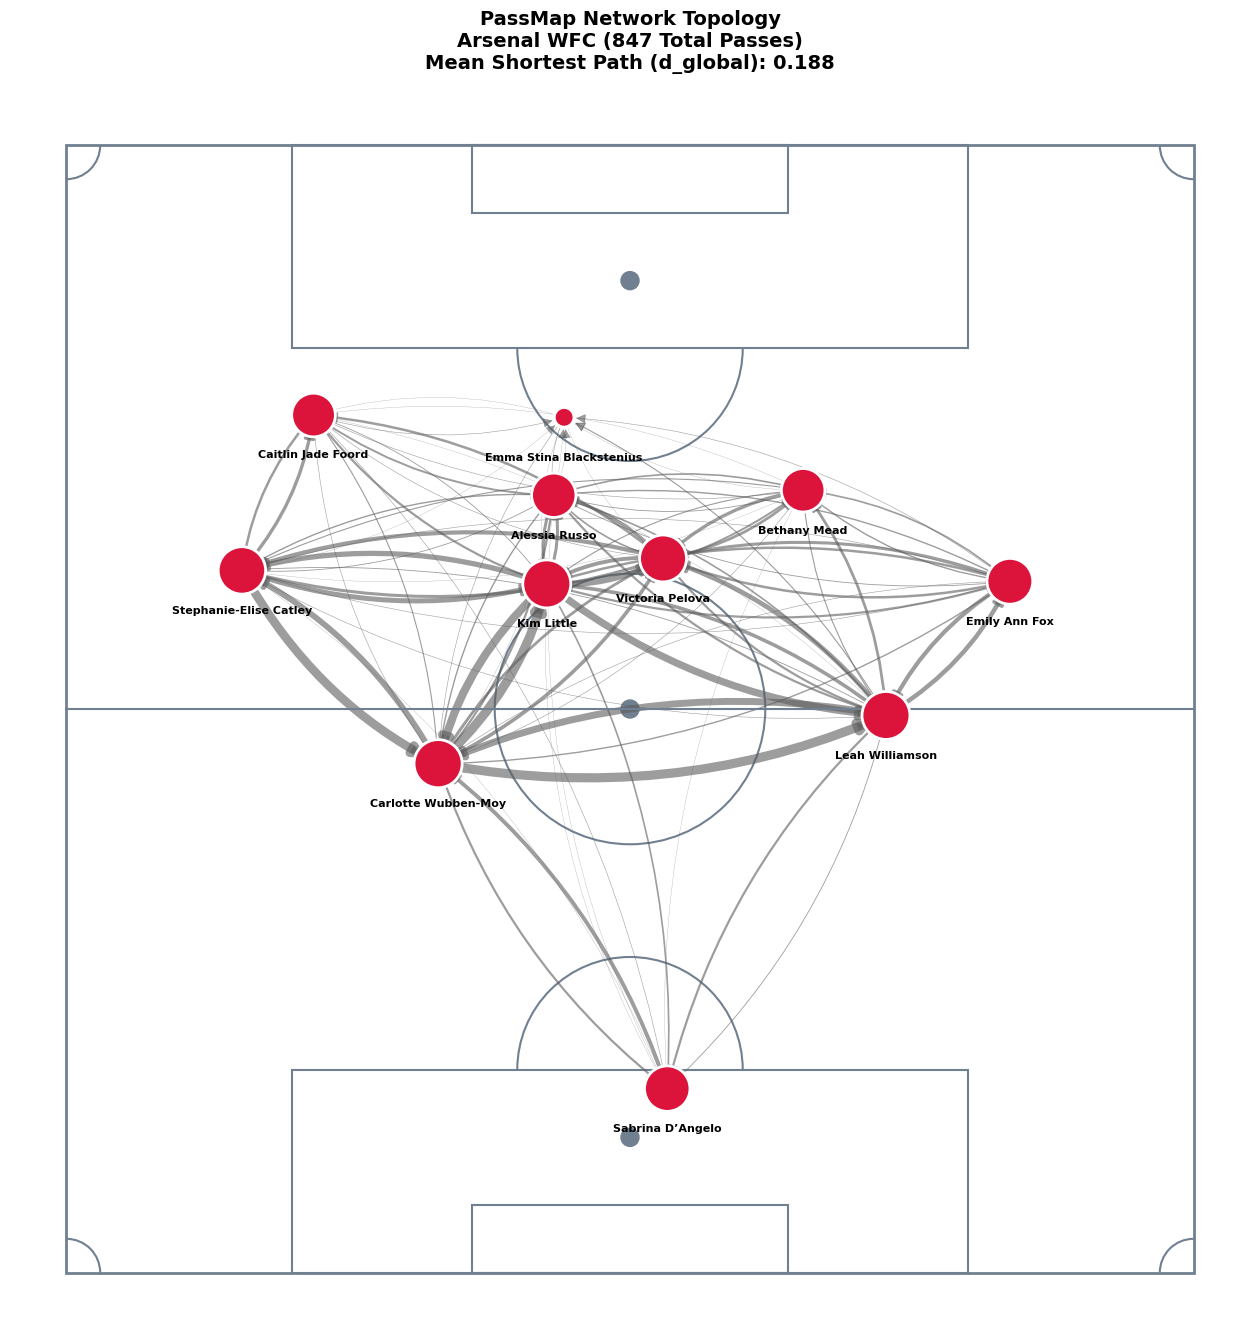

In [194]:
# 2. Extract outward path lengths (d_out) into a dictionary
d_out_dict = player_path_df["Mean Outward Path Length (d_out)"].to_dict()

# 3. Invert scores for node sizing (Smaller d_out = More efficient = LARGER node)
max_path = max(d_out_dict.values()) if d_out_dict else 1.0
path_efficiency_scores = {player: (max_path - score) for player, score in d_out_dict.items()}

# 4. Plot passmap using your updated plot_passmap_on_pitch function
plot_passmap_on_pitch(
    G=G_arsenal,
    team_name=highest_pass_match[2],
    total_passes=highest_pass_match[3],
    node_scores=path_efficiency_scores,
    metric_name="Mean Shortest Path (d_global)",
    global_metric=f"{d_global_arsenal:.3f}"
)

#### ASP Heatmap

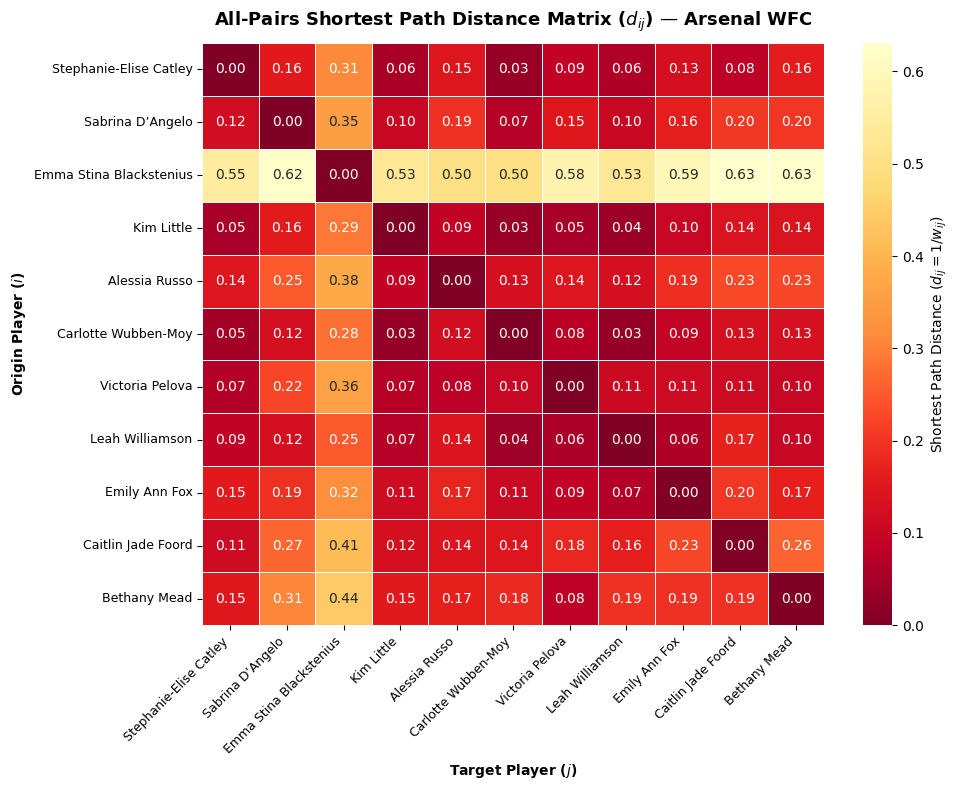

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_distance_matrix_heatmap(distance_matrix_df, team_name="Arsenal WFC"):
    """Plots the N x N All-Pairs Shortest Path Distance Matrix as a Heatmap."""
    fig, ax = plt.subplots(figsize=(10, 8), facecolor="#ffffff")

    # Plot Heatmap (YlOrRd_r palette: dark red = short/easy path, pale yellow = long/difficult path)
    sns.heatmap(
        distance_matrix_df,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd_r",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Shortest Path Distance ($d_{ij} = 1 / w_{ij}$)"},
        ax=ax,
    )

    # Formatting
    ax.set_title(
        f"All-Pairs Shortest Path Distance Matrix ($d_{{ij}}$) — {team_name}",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Target Player ($j$)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Origin Player ($i$)", fontsize=10, fontweight="bold")

    # Rotate labels for readability
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()


# ==============================================================================
# EXECUTION
# ==============================================================================
plot_distance_matrix_heatmap(
    distance_matrix_df=dist_matrix_df, team_name=highest_pass_match[2]
)

#### ASP Scatterplot

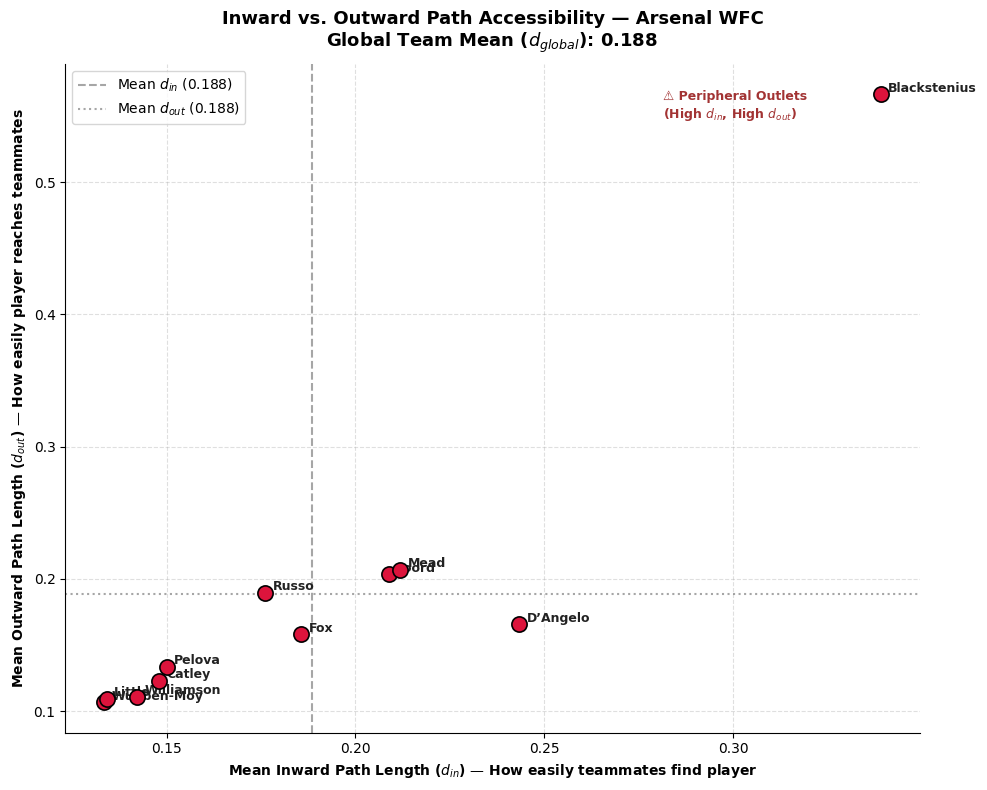

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_path_length_scatterplot(player_path_df, d_global, team_name="Arsenal WFC"):
    """
    Plots a quadrant scatter plot comparing Mean Outward Path Length (d_out) 
    vs. Mean Inward Path Length (d_in) for each player.
    """
    fig, ax = plt.subplots(figsize=(10, 8), facecolor="#ffffff")
    
    # 1. Scatter Plot
    sns.scatterplot(
        data=player_path_df,
        x="Mean Inward Path Length (d_in)",
        y="Mean Outward Path Length (d_out)",
        s=120,
        color="crimson",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
        ax=ax
    )
    
    # 2. Add Mean Reference Lines (Quadrant Dividers)
    mean_in = player_path_df["Mean Inward Path Length (d_in)"].mean()
    mean_out = player_path_df["Mean Outward Path Length (d_out)"].mean()
    
    ax.axvline(mean_in, color="#808080", linestyle="--", alpha=0.7, label=f"Mean $d_{{in}}$ ({mean_in:.3f})")
    ax.axhline(mean_out, color="#808080", linestyle=":", alpha=0.7, label=f"Mean $d_{{out}}$ ({mean_out:.3f})")
    
    # 3. Annotate Player Names
    for player, row in player_path_df.iterrows():
        short_name = player.split()[-1]  # Extract surname for clean plotting
        ax.text(
            row["Mean Inward Path Length (d_in)"] + 0.002,
            row["Mean Outward Path Length (d_out)"] + 0.002,
            short_name,
            fontsize=9,
            fontweight="bold",
            color="#222222"
        )
        
    # 4. Add Quadrant Tactical Labels
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # High d_in, High d_out (Bottom Right quadrant of plot area)
    ax.text(xlim[1] - (xlim[1]-xlim[0])*0.30, ylim[1] - (ylim[1]-ylim[0])*0.08, 
            "⚠ Peripheral Outlets\n(High $d_{in}$, High $d_{out}$)", 
            fontsize=9, fontweight="bold", color="darkred", alpha=0.8)
    
    # 5. Styling & Labels
    ax.set_title(
        f"Inward vs. Outward Path Accessibility — {team_name}\nGlobal Team Mean ($d_{{global}}$): {d_global:.3f}",
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Mean Inward Path Length ($d_{in}$) — How easily teammates find player", fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean Outward Path Length ($d_{out}$) — How easily player reaches teammates", fontsize=10, fontweight="bold")
    
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left")
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
plot_path_length_scatterplot(
    player_path_df=player_path_df,
    d_global=d_global_arsenal,
    team_name=highest_pass_match[2]
)

#### Plotting Individual Shortest Paths

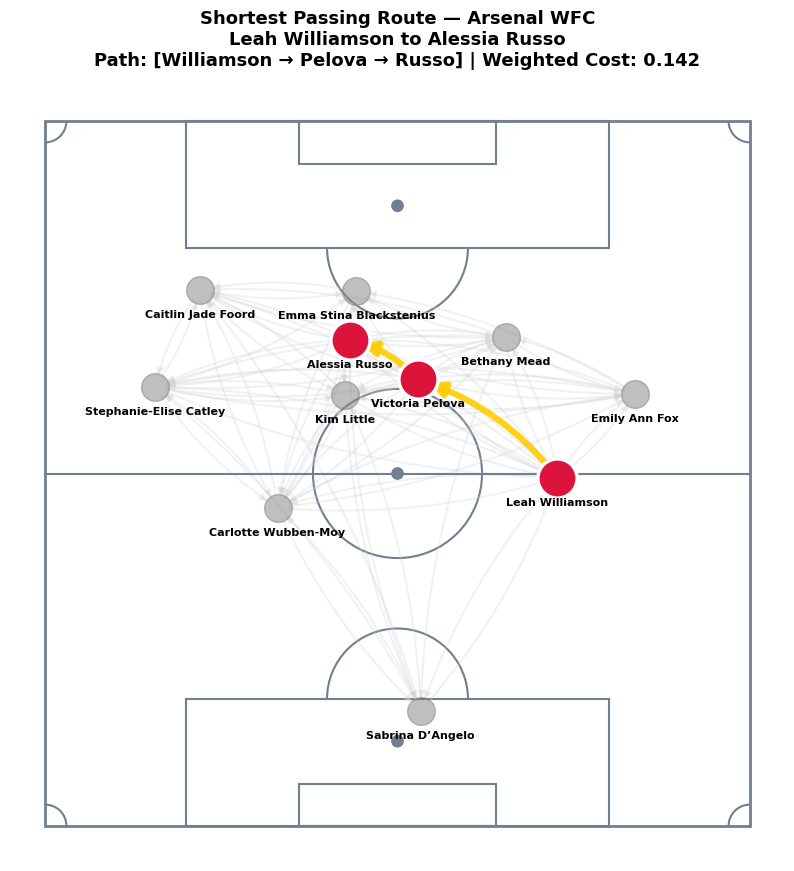

In [192]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_shortest_path_on_pitch(
    G, source_player, target_player, team_name="Arsenal WFC"
):
    """Computes and overlays the shortest passing path between two players

    on top of the full team passmap topology.
    """
    # 1. Ensure distance weights exist (distance = 1 / weight)
    G_dist = G.copy()
    for u, v, data in G_dist.edges(data=True):
        w = data.get("weight", 1)
        data["distance"] = 1.0 / w if w > 0 else float("inf")

    # 2. Compute shortest path (nodes and path length)
    try:
        path_nodes = nx.shortest_path(
            G_dist, source=source_player, target=target_player, weight="distance"
        )
        path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
        path_length = nx.shortest_path_length(
            G_dist, source=source_player, target=target_player, weight="distance"
        )
    except nx.NetworkXNoPath:
        print(f"No valid path exists between {source_player} and {target_player}.")
        return

    # 3. Setup canvas and pitch
    fig, ax = plt.subplots(figsize=(10, 14), facecolor="#ffffff")
    draw_vertical_pitch(ax=ax)

    pos_vertical = {
        node: (data["y"], data["x"]) for node, data in G.nodes(data=True)
    }
    label_pos = {
        node: (coords[0], coords[1] - 3.5) for node, coords in pos_vertical.items()
    }

    # Separate background edges from shortest path edges
    bg_edges = [e for e in G.edges() if e not in path_edges]

    # 4. Draw background edges (subtle grey)
    nx.draw_networkx_edges(
        G,
        pos_vertical,
        edgelist=bg_edges,
        ax=ax,
        edge_color="#d3d3d3",
        alpha=0.3,
        width=1.5,
        arrowsize=10,
        connectionstyle="arc3,rad=0.1",
    )

    # 5. Draw shortest path edges (thick, highlighted crimson/gold)
    nx.draw_networkx_edges(
        G,
        pos_vertical,
        edgelist=path_edges,
        ax=ax,
        edge_color="#ffcc00",  # High-visibility gold/yellow
        alpha=0.9,
        width=4.5,
        arrowsize=20,
        connectionstyle="arc3,rad=0.15",
    )

    # 6. Draw background nodes vs. path nodes
    bg_nodes = [n for n in G.nodes() if n not in path_nodes]

    nx.draw_networkx_nodes(
        G,
        pos_vertical,
        nodelist=bg_nodes,
        ax=ax,
        node_size=400,
        node_color="#808080",
        alpha=0.5,
    )

    nx.draw_networkx_nodes(
        G,
        pos_vertical,
        nodelist=path_nodes,
        ax=ax,
        node_size=800,
        node_color="crimson",
        edgecolors="white",
        linewidths=2.5,
    )

    # 7. Labels
    nx.draw_networkx_labels(
        G,
        label_pos,
        ax=ax,
        font_size=8,
        font_color="black",
        font_weight="bold",
    )

    # 8. Title
    path_str = " → ".join([p.split()[-1] for p in path_nodes])
    plt.title(
        f"Shortest Passing Route — {team_name}\n"
        f"{source_player} to {target_player}\n"
        f"Path: [{path_str}] | Weighted Cost: {path_length:.3f}",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )

    plt.show()


# ==============================================================================
# EXECUTION
# ==============================================================================
plot_shortest_path_on_pitch(
    G=G_arsenal,
    source_player="Leah Williamson",
    target_player="Alessia Russo",
    team_name=highest_pass_match[2],
)

### Betweenness

#### Computation Function

In [149]:
import numpy as np
import pandas as pd
import networkx as nx

def calculate_betweenness_centrality(G, distance_matrix_df=None):
    """
    Computes weighted shortest-path betweenness centrality for a directed passing network.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        distance_matrix_df (pd.DataFrame, optional): Pre-computed distance matrix from Part 1.
        
    Returns:
        betweenness_df (pd.DataFrame): Player-level betweenness centrality scores.
    """
    # 1. Create a copy of the graph to ensure the distance attribute is present
    G_dist = G.copy()
    
    for u, v, data in G_dist.edges(data=True):
        weight = data.get('weight', 1)
        if weight > 0:
            data['distance'] = 1.0 / weight
        else:
            data['distance'] = np.inf

    # 2. Calculate Weighted Betweenness Centrality using shortest paths (normalized=True by default)
    # NetworkX automatically accounts for directed edges and path weights.
    betweenness_dict = nx.betweenness_centrality(G_dist, weight='distance', normalized=True)
    
    # 3. Compile into a DataFrame
    nodes = list(G_dist.nodes())
    betweenness_data = []
    
    for node in nodes:
        betweenness_data.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "Betweenness Centrality g(i)": betweenness_dict.get(node, 0.0)
        })
        
    betweenness_df = pd.DataFrame(betweenness_data).set_index("Player")
    
    # Sort by betweenness score descending (highest bridge/control value first)
    betweenness_df = betweenness_df.sort_values(by="Betweenness Centrality g(i)", ascending=False)
    
    return betweenness_df, betweenness_dict

#### Output Table

In [151]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

betweenness_df, betweenness_dict_arsenal = calculate_betweenness_centrality(G_arsenal)

print("\n" + "="*80)
print("Part 2: Betweenness Centrality Analysis - Arsenal WFC")
print("="*80)
print(betweenness_df.to_string())


Part 2: Betweenness Centrality Analysis - Arsenal WFC
                                          Position  Betweenness Centrality g(i)
Player                                                                         
Carlotte Wubben-Moy               Left Center Back                     0.322222
Leah Williamson                  Right Center Back                     0.300000
Kim Little                 Left Defensive Midfield                     0.177778
Victoria Pelova           Right Defensive Midfield                     0.138889
Stephanie-Elise Catley                   Left Back                     0.122222
Sabrina D’Angelo                        Goalkeeper                     0.000000
Emma Stina Blackstenius             Center Forward                     0.000000
Alessia Russo            Center Attacking Midfield                     0.000000
Emily Ann Fox                           Right Back                     0.000000
Caitlin Jade Foord                       Left Wing               

#### Visual: Bar Chart

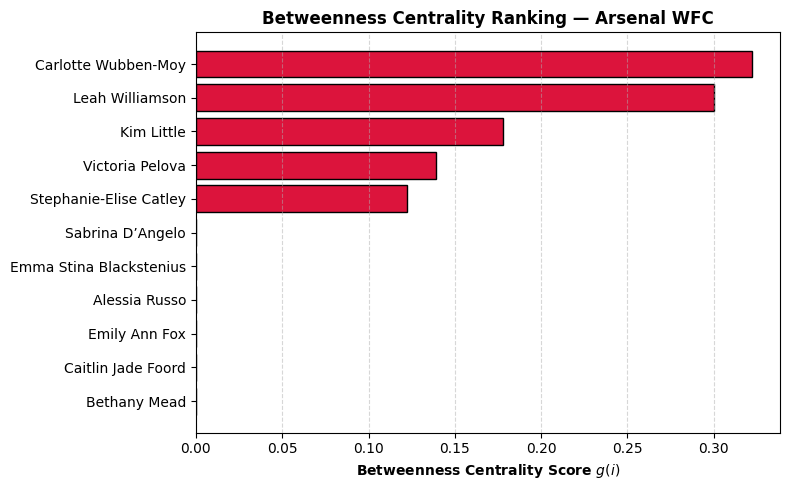

In [185]:
import matplotlib.pyplot as plt

# 1. Reset index and extract data
df_plot = betweenness_df_arsenal.reset_index()
players = df_plot["Player"]
scores = df_plot["Betweenness Centrality g(i)"]

# 2. Plot horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(players, scores, color="crimson", edgecolor="black")

# 3. Format chart (invert y-axis so highest score is at the top)
plt.gca().invert_yaxis()
plt.xlabel("Betweenness Centrality Score $g(i)$", fontweight="bold")
plt.title("Betweenness Centrality Ranking — Arsenal WFC", fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Visual Node Adjusted Network

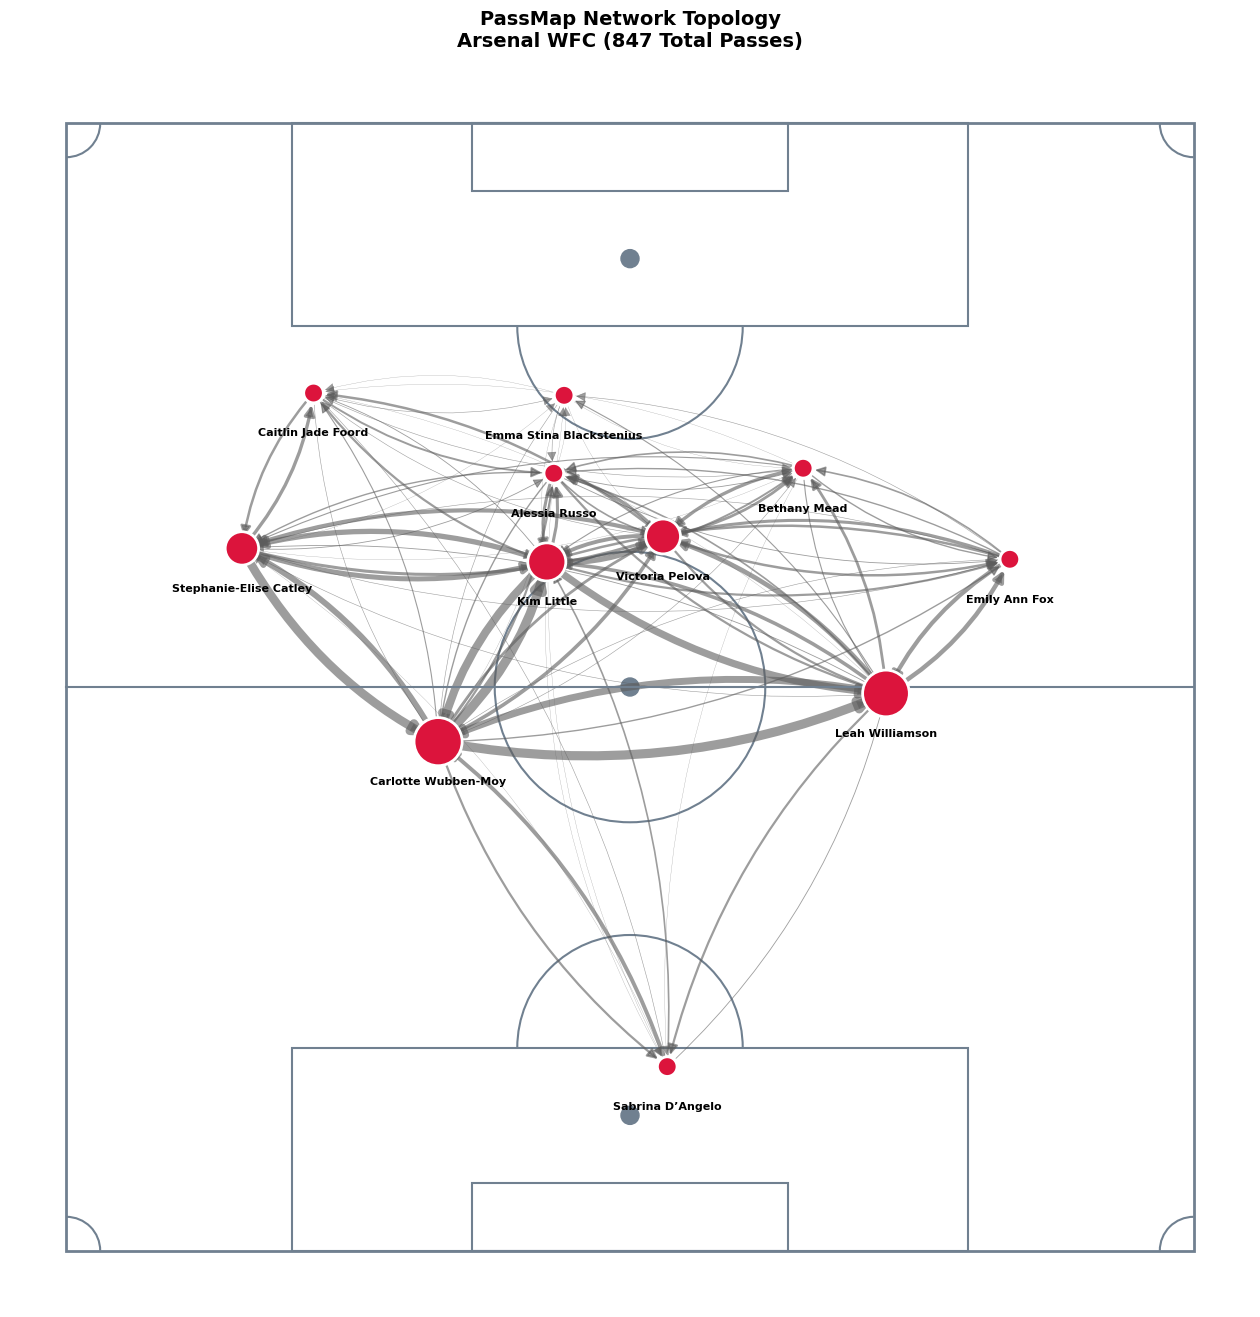

In [191]:
# 1. Compute betweenness scores
betweenness_df_arsenal, betweenness_dict_arsenal = calculate_betweenness_centrality(G_arsenal)

# 2. Plot passmap with nodes sized by betweenness centrality
plot_passmap_on_pitch(
    G=G_arsenal, 
    team_name=highest_pass_match[2], 
    total_passes=highest_pass_match[3],
    node_scores=betweenness_dict_arsenal,
)

### Clustering Triads

In [140]:
import itertools
import numpy as np
import pandas as pd
import networkx as nx

def calculate_transitive_triad_intensity(G):
    """
    Computes Pure Transitive Triad Intensity (I_transitive) for a weighted passing network.
    Exclusively evaluates progressive wall-passes and multi-option forward combinations:
    (a -> b, b -> c, a -> c), weighted by minimum channel throughput min(w_ab, w_bc, w_ac).
    
    Returns:
        global_I_team (float): Average team-wide transitive triad intensity.
        triad_df (pd.DataFrame): Player-level Transitive Triad Intensity scores.
        active_triads (list): List of detected transitive triads with players, capacities, and permutations.
    """
    nodes = list(G.nodes())
    player_triad_scores = {node: 0.0 for node in nodes}
    active_triads = []
    
    # Extract weighted adjacency matrix (NumPy)
    W = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    idx_to_node = {idx: node for node, idx in node_to_idx.items()}
    
    # Iterate over all unique 3-player combinations (i, j, k)
    for triplet in itertools.combinations(nodes, 3):
        i, j, k = triplet
        idx_i, idx_j, idx_k = node_to_idx[i], node_to_idx[j], node_to_idx[k]
        
        triplet_capacity_sum = 0.0
        triplet_permutations = []
        perms = list(itertools.permutations([idx_i, idx_j, idx_k]))
        
        # Loop through cominations of a,b,c
        for p in perms:
            a, b, c = p
            w_ab = W[a, b]
            w_bc = W[b, c]
            w_ac = W[a, c]
            
            # EXCLUSIVELY TRANSITIVE: a -> b, b -> c, a -> c
            # atleast one pass in each relationship forms a cluster
            if w_ab > 0 and w_bc > 0 and w_ac > 0:
                cap = min(w_ab, w_bc, w_ac) 
                triplet_capacity_sum += cap # cluster is weighted by lowest pair
                triplet_permutations.append({
                    "origin": idx_to_node[a],
                    "intermediate": idx_to_node[b],
                    "target": idx_to_node[c],
                    "capacity": cap
                })
                
        # If valid transitive structures exist for this 3-player set
        if triplet_capacity_sum > 0:
            player_triad_scores[i] += triplet_capacity_sum
            player_triad_scores[j] += triplet_capacity_sum
            player_triad_scores[k] += triplet_capacity_sum
            
            active_triads.append({
                "players": (i, j, k),
                "total_capacity": triplet_capacity_sum,
                "permutations": triplet_permutations
            })

    # Compute Team-Wide Global Average
    global_I_team = float(np.mean(list(player_triad_scores.values())))
    
    # Format into Player DataFrame
    triad_data = []
    for node in nodes:
        triad_data.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "Transitive Triad Intensity (I_transitive)": round(player_triad_scores[node], 2)
        })
        
    player_triad_df = pd.DataFrame(triad_data).set_index("Player")
    player_triad_df = player_triad_df.sort_values(by="Transitive Triad Intensity (I_transitive)", ascending=False)
    
    # Sort active triads by highest bottleneck capacity
    active_triads = sorted(active_triads, key=lambda x: x["total_capacity"], reverse=True)
    
    return global_I_team, player_triad_df, active_triads

In [141]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

global_I_trans_arsenal, triad_df_trans_arsenal, active_triads = calculate_transitive_triad_intensity(G_arsenal)

print("\n" + "="*80)
print("Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC")
print("="*80)
print(f"Global Team Transitive Triad Intensity (I_team): {global_I_trans_arsenal:.2f} pass units")

print("\n" + "="*80)
print("Player-Level Transitive Triad Summary (Ranked by I_transitive)")
print("="*80)
print(triad_df_trans_arsenal.to_string())

print("\n" + "="*80)
print("Top 10 Active Transitive Triads")
print("="*80)
top_triads_summary = []
for idx, t in enumerate(active_triads[:10], start=1):
    p1, p2, p3 = t["players"]
    top_triads_summary.append({
        "Rank": idx,
        "Player 1 (Origin/Target)": p1,
        "Player 2 (Intermediate)": p2,
        "Player 3 (Target/Origin)": p3,
        "Total Capacity (Pass Units)": round(t["total_capacity"], 2)
    })

top_triads_df = pd.DataFrame(top_triads_summary).set_index("Rank")
print(top_triads_df.to_string())


Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC
Global Team Transitive Triad Intensity (I_team): 582.55 pass units

Player-Level Transitive Triad Summary (Ranked by I_transitive)
                                          Position  Transitive Triad Intensity (I_transitive)
Player                                                                                       
Kim Little                 Left Defensive Midfield                                     1069.0
Victoria Pelova           Right Defensive Midfield                                      927.0
Carlotte Wubben-Moy               Left Center Back                                      864.0
Leah Williamson                  Right Center Back                                      814.0
Stephanie-Elise Catley                   Left Back                                      645.0
Alessia Russo            Center Attacking Midfield                                      641.0
Emily Ann Fox                           Rig

### Polygon Triad Plot

In [131]:
from matplotlib.patches import Polygon

def plot_transitive_triads(ax, active_triads, node_positions, top_n=4, palette=None):
    """
    Plots the top active transitive triads as shaded polygon patches and labels 
    them on a vertical football pitch axis.
    
    Parameters:
        ax (matplotlib.axes.Axes): The matplotlib axis with the drawn pitch.
        active_triads (list): List of active triads returned by calculate_transitive_triad_intensity().
        node_positions (dict): Dictionary mapping player names to remapped vertical (X, Y) coordinates.
        top_n (int): Number of top-capacity triads to render.
        palette (list, optional): List of hex color strings to cycle through.
    """
    if palette is None:
        palette = ["#00E676", "#FFD600", "#00E5FF", "#FF6D00", "#E040FB", "#7C4DFF"]

    for idx, triad in enumerate(active_triads[:top_n]):
        p1, p2, p3 = triad["players"]
        color = palette[idx % len(palette)]

        # Retrieve coordinates for the 3 players
        coords = [node_positions.get(p) for p in (p1, p2, p3) if p in node_positions]

        # Only plot if all 3 player positions exist
        if len(coords) == 3:
            poly = Polygon(
                coords,
                closed=True,
                facecolor=color,
                edgecolor=color,
                alpha=0.25,  # Semi-transparent to show overlapping density
                linewidth=2.0,
                linestyle="-",
                zorder=3,
            )
            ax.add_patch(poly)

            # Compute triangle centroid to anchor label badge
            centroid_x = sum([c[0] for c in coords]) / 3.0
            centroid_y = sum([c[1] for c in coords]) / 3.0

            short_p1 = str(p1).split()[-1]
            short_p2 = str(p2).split()[-1]
            short_p3 = str(p3).split()[-1]

            ax.text(
                centroid_x,
                centroid_y,
                f"▲ {short_p1}-{short_p2}-{short_p3}\n({triad['total_capacity']:.1f} pass units)",
                color=color,
                fontsize=7.5,
                ha="center",
                va="center",
                weight="bold",
                zorder=4,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="#101820",
                    edgecolor=color,
                    linewidth=1,
                    alpha=0.85,
                ),
            )

In [133]:
def plot_player_nodes(ax, G, node_positions, node_scores, team_baseline):
    """
    Plots player nodes and name/score labels on a vertical pitch axis dynamically 
    based on any given metric score and team baseline.
    
    Parameters:
        ax (matplotlib.axes.Axes): The matplotlib axis with the drawn pitch.
        G (nx.DiGraph): The network graph containing the nodes.
        node_positions (dict): Dictionary mapping player names to remapped vertical (X, Y) coordinates.
        node_scores (dict): Dictionary mapping player names to their metric scores (e.g., I_transitive, degree, etc.).
        team_baseline (float): Threshold score used to color-code nodes (above vs. below baseline).
    """
    max_score = max(node_scores.values()) if node_scores else 1000.0

    for node in G.nodes():
        if node not in node_positions:
            continue
            
        x, y = node_positions[node]
        score = node_scores.get(node, 0.0)

        # Size nodes relative to score
        node_size = (score / max_score) * 800 + 150

        # Color-code nodes based on Team Baseline threshold
        node_color = "#FF3366" if score >= team_baseline else "#4A90E2"

        # Scatter Node Plot
        ax.scatter(
            x,
            y,
            s=node_size,
            c=node_color,
            edgecolors="white",
            linewidth=1.5,
            zorder=5,
        )

        # Player Name and Score Label (Extracts short name from string ID)
        short_name = str(node).split()[-1]
        ax.text(
            x,
            y - 3.5,
            f"{short_name}\n({int(score)})",
            color="white",
            fontsize=8.5,
            ha="center",
            va="center",
            weight="bold",
            zorder=6,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="#101820",
                edgecolor="none",
                alpha=0.75,
            ),
        )

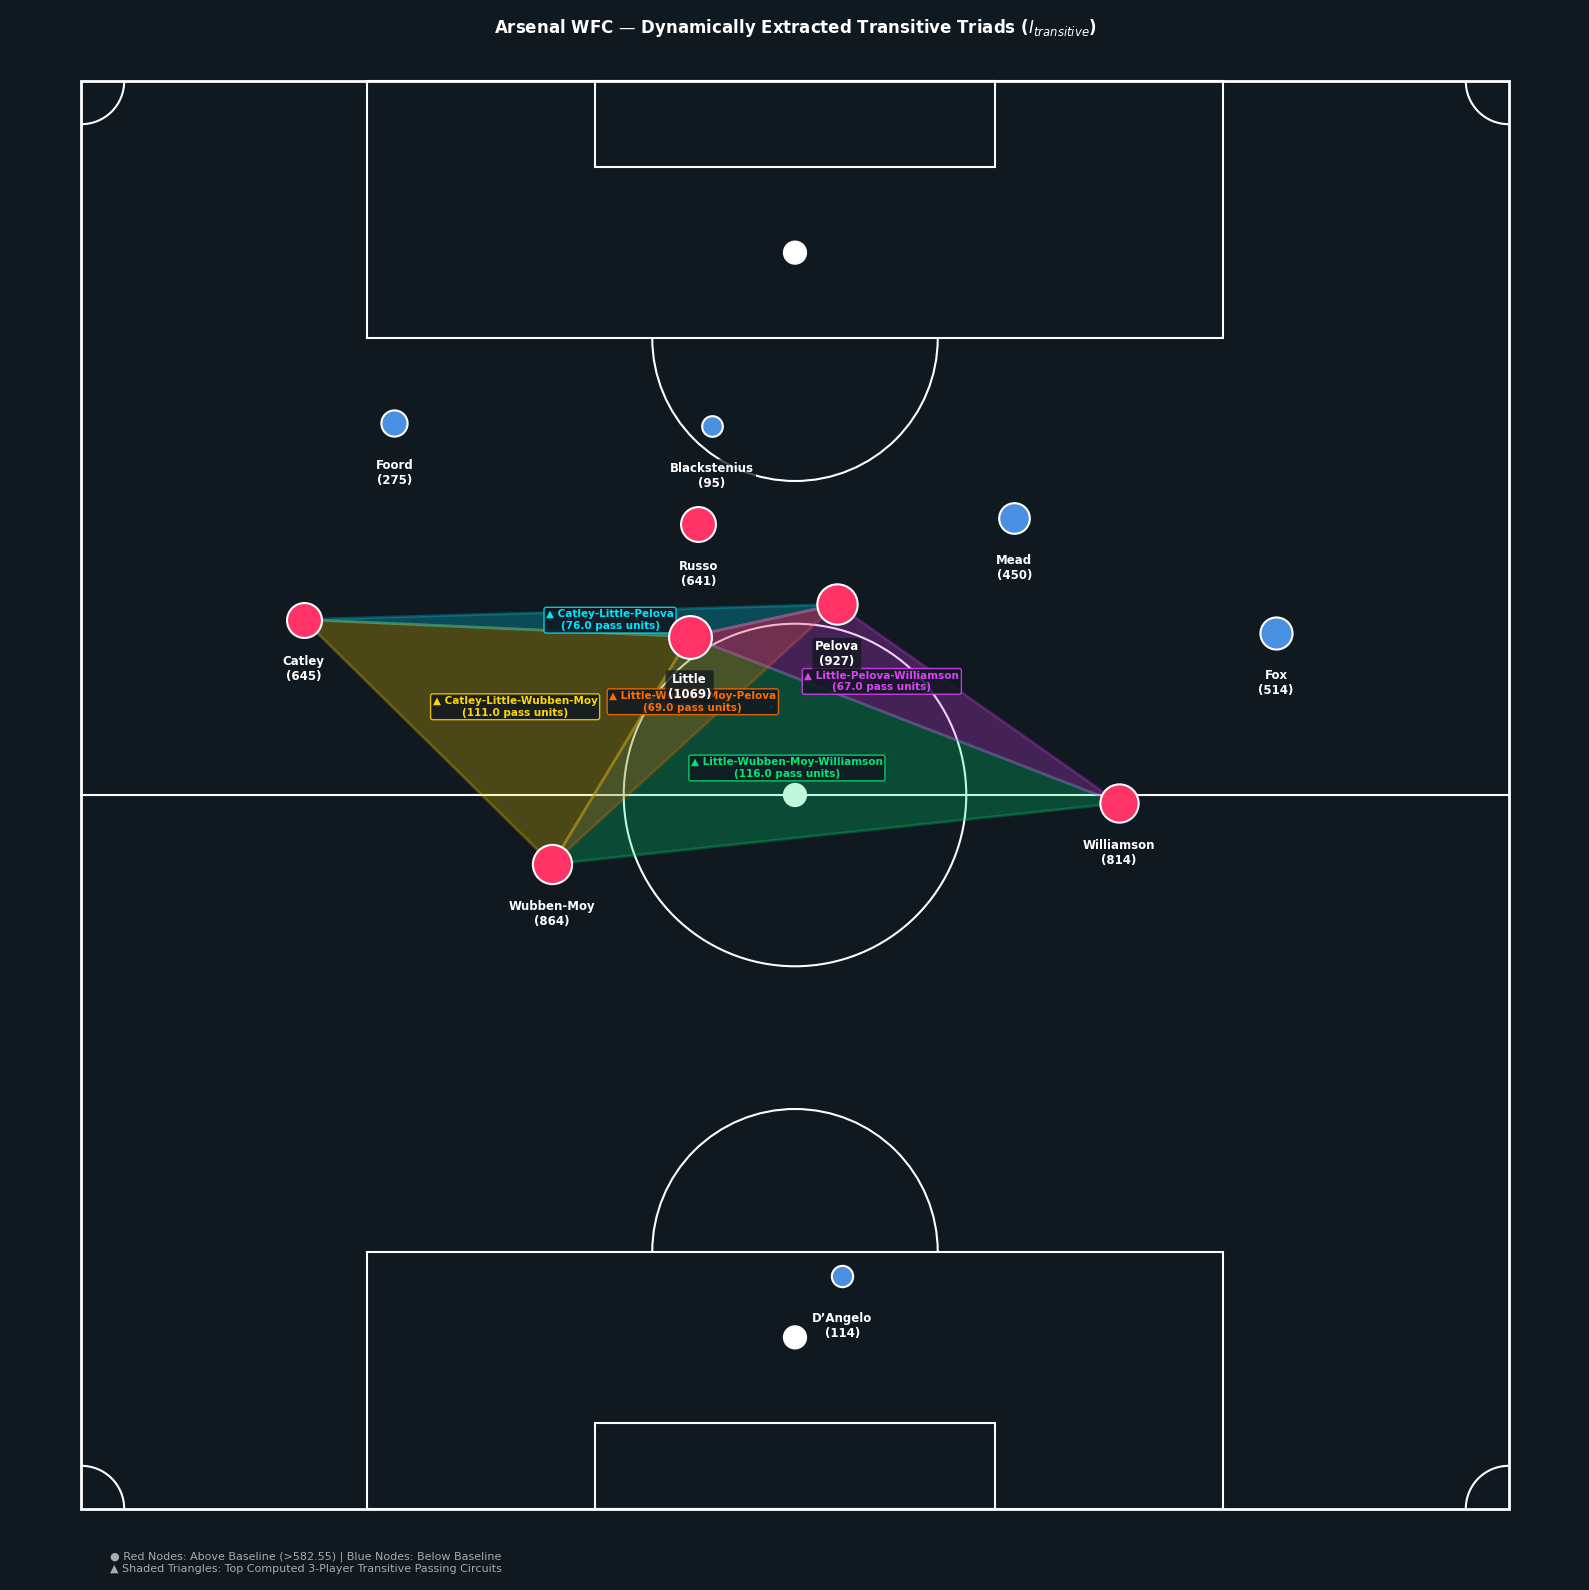

In [142]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import networkx as nx

# Run the updated function on G_arsenal
global_I_trans_arsenal, triad_df_trans_arsenal, active_triads = calculate_transitive_triad_intensity(G_arsenal)

# Extract coordinates and swap (x, y) -> (y, x) for vertical orientation
raw_positions = nx.get_node_attributes(G_arsenal, "pos")
node_positions = {node: (pos[1], pos[0]) for node, pos in raw_positions.items()}

node_scores = triad_df_trans_arsenal["Transitive Triad Intensity (I_transitive)"].to_dict()
TEAM_BASELINE = global_I_trans_arsenal

# Select the top N highest capacity triads to render as filled polygons on the pitch
TOP_N_TRIADS_TO_PLOT = 10
palette = ["#00E676", "#FFD600", "#00E5FF", "#FF6D00", "#E040FB", "#7C4DFF"]

# ==============================================================================
# PLOTTING PITCH, DYNAMIC TRIADS, & NODES
# ==============================================================================
fig, ax = plt.subplots(figsize=(16, 22))
fig.patch.set_facecolor("#101820")
draw_vertical_pitch(ax=ax, pitch_color="#101820", line_color="#ffffff")

# 2. Call the new function to draw the triangles instantly!
plot_transitive_triads(ax, active_triads, node_positions, top_n=5)

# Draw Player Nodes & Badges
plot_player_nodes(ax, G_arsenal, node_positions, node_scores, TEAM_BASELINE)

# Title & Legend Annotations
ax.text(
    50,
    103,
    "Arsenal WFC — Dynamically Extracted Transitive Triads ($I_{transitive}$)",
    color="white",
    fontsize=12,
    ha="center",
    va="bottom",
    weight="bold",
)

ax.text(
    2,
    -3,
    f"● Red Nodes: Above Baseline (>{TEAM_BASELINE:.2f}) | Blue Nodes: Below Baseline\n▲ Shaded Triangles: Top Computed 3-Player Transitive Passing Circuits",
    color="#aaaaaa",
    fontsize=8,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

### Empirical Baselines

#### Compute League Global Shortest Paths

In [ ]:
def compute_league_global_shortest_paths(integrated_match_records):
    """Computes global average shortest path (d) and pass counts for all team-match pairs in the empirical dataset.

    Parameters:
        integrated_match_records (list): List of match records, where each entry
          contains: [match_index, match_id, team_name, total_passes,
          player_list, top_11_players]

    Returns:
        league_df (pd.DataFrame): Empirical dataset of (Match_ID, Team,
        Total_Passes, d_global)
    """
    results = []

    for record in integrated_match_records:
        m_idx, m_id, team_name, total_passes, _, _ = record

        # 1. Build the network for this specific team and match
        try:
            G = build_passmap_network(record)

            # 2. Compute Global Shortest Path length using your existing pipeline
            d_global, _, _ = calculate_average_shortest_path(G)

            results.append({
                "Match_ID": m_id,
                "Team": team_name,
                "Total_Passes": total_passes,
                "d_global": d_global,
            })
        except Exception as e:
            # Safeguard for edge cases or incomplete event files
            print(f"Skipping Match {m_id} for {team_name} due to error: {e}")

    league_df = pd.DataFrame(results)
    return league_df

In [229]:
league_df_wsl = compute_league_global_shortest_paths(integrated_match_records)

PassMap Graph Successfully Built for Brighton & Hove Albion WFC (Match ID: 3913082)
• Nodes: 11 | Edges: 70 | Total Filtered Passes: 157
PassMap Graph Successfully Built for Manchester United W (Match ID: 3913082)
• Nodes: 11 | Edges: 89 | Total Filtered Passes: 436
PassMap Graph Successfully Built for Manchester City WFC (Match ID: 3913155)
• Nodes: 11 | Edges: 92 | Total Filtered Passes: 418
PassMap Graph Successfully Built for Manchester United W (Match ID: 3913155)
• Nodes: 11 | Edges: 74 | Total Filtered Passes: 313
PassMap Graph Successfully Built for Tottenham Hotspur Women (Match ID: 3913167)
• Nodes: 11 | Edges: 85 | Total Filtered Passes: 249
PassMap Graph Successfully Built for Manchester United W (Match ID: 3913167)
• Nodes: 11 | Edges: 86 | Total Filtered Passes: 427
PassMap Graph Successfully Built for Aston Villa W (Match ID: 3913175)
• Nodes: 11 | Edges: 91 | Total Filtered Passes: 501
PassMap Graph Successfully Built for West Ham United LFC (Match ID: 3913175)
• Nodes:

In [235]:
league_df_wsl.sort_values(by="d_global", ascending=True, inplace=True)
league_df_wsl

,Match_ID,Team,Total_Passes,d_global
16,3913129,Aston Villa W,620,0.174763
42,3913168,Manchester City WFC,684,0.177458
134,3912593,Manchester City WFC,680,0.180793
71,3913156,Arsenal WFC,672,0.181400
65,3913150,Manchester City WFC,659,0.181712
...,...,...,...,...
111,3913104,Bristol City WFC,155,0.752576
17,3913129,Bristol City WFC,187,0.770682
181,3913140,Bristol City WFC,154,0.819827
115,3913079,Bristol City WFC,120,0.886861


#### d_global Percentile

In [236]:
import numpy as np
import pandas as pd
from scipy import stats


def evaluate_global_d_empirical_position(
    league_df, case_study_team="Arsenal WFC", case_study_passes=847
):
    """Computes the exact percentile, rank, and z-score of the case study's d_global

    within the empirical league distribution.
    """
    # 1. Fetch case study d_global value
    case_study_row = league_df[
        (league_df["Team"] == case_study_team)
        & (league_df["Total_Passes"] == case_study_passes)
    ]
    case_study_d = (
        case_study_row["d_global"].values[0]
        if not case_study_row.empty
        else 0.1884
    )

    # 2. Basic Distribution Statistics
    mean_d = league_df["d_global"].mean()
    std_d = league_df["d_global"].std()
    min_d = league_df["d_global"].min()
    max_d = league_df["d_global"].max()

    # 3. Compute Percentile Rank & Standardized Z-Score
    # Lower d_global = Higher circulation efficiency
    percentile = stats.percentileofscore(
        league_df["d_global"], case_study_d, kind="strict"
    )
    z_score = (case_study_d - mean_d) / std_d

    # 4. Compute Absolute Numerical Rank (1 = Lowest/Most Efficient d_global)
    sorted_df = league_df.sort_values(by="d_global", ascending=True).reset_index(
        drop=True
    )
    rank = (
        sorted_df[
            (sorted_df["Team"] == case_study_team)
            & (sorted_df["Total_Passes"] == case_study_passes)
        ].index[0]
        + 1
    )

    # Print Summary Report
    print("=" * 80)
    print("EMPIRICAL POSITION REPORT: GLOBAL SHORTEST PATH (d_global)")
    print("=" * 80)
    print(f"Case Study Match:            {case_study_team} ({case_study_passes} Passes)")
    print(f"Case Study d_global:         {case_study_d:.4f} topological units")
    print("-" * 80)
    print(f"League Distribution Range:   [{min_d:.4f} to {max_d:.4f}]")
    print(f"League Mean d_global:        {mean_d:.4f} ± {std_d:.4f}")
    print("-" * 80)
    print(f"Absolute Rank:               {rank} / {len(league_df)} matches (1 = Lowest/Most Efficient d)")
    print(f"Percentile Score:            {percentile:.2f}% of league matches have a lower d_global")
    print(f"Z-Score:                     {z_score:.2f} standard deviations from mean")
    print("=" * 80)

    return sorted_df


# ==============================================================================
# EXECUTION
# ==============================================================================
sorted_league_df = evaluate_global_d_empirical_position(
    league_df_wsl, case_study_team="Arsenal WFC", case_study_passes=847
)

EMPIRICAL POSITION REPORT: GLOBAL SHORTEST PATH (d_global)
Case Study Match:            Arsenal WFC (847 Passes)
Case Study d_global:         0.1884 topological units
--------------------------------------------------------------------------------
League Distribution Range:   [0.1748 to 0.9645]
League Mean d_global:        0.3521 ± 0.1263
--------------------------------------------------------------------------------
Absolute Rank:               10 / 264 matches (1 = Lowest/Most Efficient d)
Percentile Score:            3.41% of league matches have a lower d_global
Z-Score:                     -1.30 standard deviations from mean


#### Distribution of Pass Volumes

##### Graph

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_league_pass_distribution(
    league_df, case_study_team="Arsenal WFC", case_study_passes=847
):
    """Plots the empirical distribution of total pass volumes across all team-matches in the dataset."""
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="#ffffff")

    # 1. Plot Histogram + KDE with explicit bin edges from 0 to 1000 in steps of 50
    sns.histplot(
        data=league_df,
        x="Total_Passes",
        kde=True,
        color="#2b5c8f",
        bins=range(0, 1001, 100),  # Creates [0, 50, 100, ..., 1000]
        ax=ax,
    )

    # 2. Add Reference Lines
    league_mean = league_df["Total_Passes"].mean()

    ax.axvline(
        case_study_passes,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"{case_study_team} Case Study ({case_study_passes} Passes)",
    )

    ax.axvline(
        league_mean,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label=f"League Mean ({league_mean:.1f} Passes)",
    )

    # 3. Formatting
    ax.set_title(
        f"Empirical League Distribution of Team Pass Volumes (N={len(league_df)})",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )

    ax.set_xlabel("Total Team Passes in Match", fontsize=10, fontweight="bold")
    ax.set_ylabel("Match Frequency", fontsize=10, fontweight="bold")
    ax.set_xlim(0, 1000)  # Align x-axis bounds neatly to the bin range
    ax.legend(loc="upper right")
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

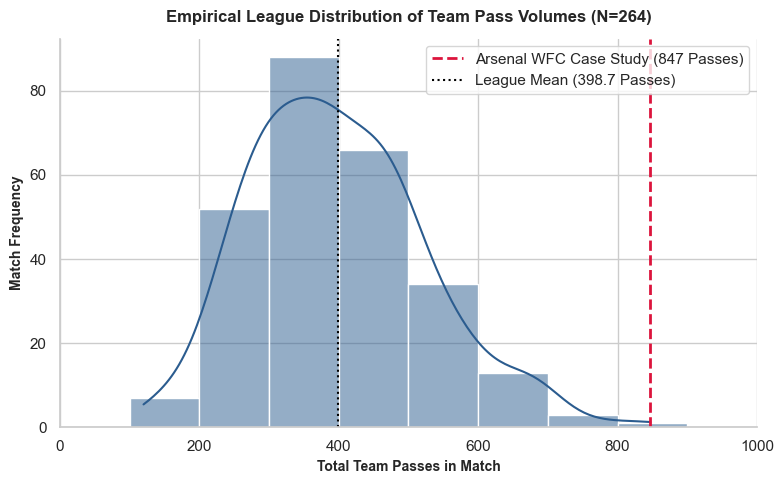

In [241]:
# ==============================================================================
# EXECUTION
# ==============================================================================
plot_league_pass_distribution(
    league_df_wsl, case_study_team="Arsenal WFC", case_study_passes=847
)

##### Table

In [247]:
# ==========================================================================
# BIN COUNT TABLE GENERATION
# ==========================================================================
bin_edges = list(range(0, 1001, 100))

bin_counts = pd.cut(
        league_df_wsl["Total_Passes"], bins=bin_edges, right=False
    ).value_counts(sort=False)

bin_table = pd.DataFrame({
        "Pass Range": [
            f"{int(b.left)}–{int(b.right) - 1}" for b in bin_counts.index
        ],
        "Match Count (n)": bin_counts.values,
        "Percentage (%)": (bin_counts.values / len(league_df_wsl) * 100).round(2),
    })

bin_table

,Pass Range,Match Count (n),Percentage (%)
0,0–99,0,0.00
1,100–199,7,2.65
2,200–299,52,19.70
3,300–399,88,33.33
4,400–499,66,25.00
5,500–599,34,12.88
6,600–699,13,4.92
7,700–799,3,1.14
8,800–899,1,0.38
9,900–999,0,0.00


##### Passes 300 to 399, Formations

In [250]:
import pandas as pd


def generate_formation_table_in_bin(
    integrated_match_records, lower_pass_bound=300, upper_pass_bound=399
):
    """Filters integrated match records by pass volume and produces a summary table

    of the starting tactical formations used within that volume range.
    """
    # 1. Extract records into a working DataFrame
    records_data = []
    for record in integrated_match_records:
        records_data.append({
            "Match_ID": record[1],
            "Team": record[2],
            "Formation": str(record[3]),
            "Total_Passes": record[4],
        })

    df = pd.DataFrame(records_data)

    # 2. Filter for matches within the specified pass volume bin
    bin_df = df[
        (df["Total_Passes"] >= lower_pass_bound)
        & (df["Total_Passes"] <= upper_pass_bound)
    ].copy()

    total_in_bin = len(bin_df)

    if total_in_bin == 0:
        print(
            f"No matches found in the pass range {lower_pass_bound}–{upper_pass_bound}."
        )
        return pd.DataFrame()

    # 3. Compute formation counts and percentages
    formation_summary = (
        bin_df["Formation"]
        .value_counts()
        .reset_index()
        .rename(
            columns={
                "index": "Starting Formation",
                "Formation": "Starting Formation",
                "count": "Match Count (n)",
            }
        )
    )

    # Handle pandas version compatibility for value_counts column naming
    if "count" in formation_summary.columns:
        formation_summary = formation_summary.rename(
            columns={"count": "Match Count (n)"}
        )

    formation_summary["Percentage (%)"] = (
        (formation_summary["Match Count (n)"] / total_in_bin) * 100
    ).round(2)

    # Console Diagnostic Print
    print("=" * 60)
    print(
        f"FORMATION BREAKDOWN: {lower_pass_bound}–{upper_pass_bound} PASS BIN"
    )
    print("=" * 60)
    print(f"Total Matches in Bin (n): {total_in_bin}")
    print(f"Unique Formations:        {len(formation_summary)}")
    print("=" * 60)

    return formation_summary.reset_index(drop=True)


# ==============================================================================
# EXECUTION
# ==============================================================================
formation_table_300_399 = generate_formation_table_in_bin(
    integrated_match_records, lower_pass_bound=300, upper_pass_bound=399
)

# Display table
formation_table_300_399

FORMATION BREAKDOWN: 300–399 PASS BIN
Total Matches in Bin (n): 88
Unique Formations:        11


,Starting Formation,Match Count (n),Percentage (%)
0,4231,23,26.14
1,343,19,21.59
2,352,12,13.64
3,4141,11,12.50
4,433,9,10.23
5,442,7,7.95
6,3412,3,3.41
7,451,1,1.14
8,4411,1,1.14
9,41212,1,1.14


#### Scatter Pass Volume vs ASP

In [214]:
def plot_volume_bias_scatterplot(
    league_df,
    case_study_team="Arsenal WFC",
    case_study_passes=847,
    bin_width=50,
):
    """Plots Total Passes vs.

    Global Average Shortest Path (d) to expose volume bias and the sub-filter
    bin.
    """
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="#ffffff")

    # 1. Fetch case study d_global value safely
    case_study_row = league_df[(league_df["Team"] == case_study_team) & (league_df["Total_Passes"] == case_study_passes)]
    case_study_d = case_study_row["d_global"].values[0]

    # 2. Scatter Plot & Trendline
    sns.scatterplot(
        data=league_df,
        x="Total_Passes",
        y="d_global",
        alpha=0.6,
        color="#2b5c8f",
        ax=ax,
    )
    sns.regplot(
        data=league_df,
        x="Total_Passes",
        y="d_global",
        scatter=False,
        color="black",
        ax=ax,
        line_kws={"linestyle": "--", "linewidth": 1.5},
    )

    # 3. Highlight Case Study Point
    ax.scatter(
        [case_study_passes],
        [case_study_d],
        color="crimson",
        s=120,
        zorder=5,
        edgecolor="black",
        label=f"Case Study Match ($d = {case_study_d:.3f}$)",
    )

    # 4. Highlight Tactical Sub-Filtering Bin
    lower_bound = case_study_passes - bin_width
    upper_bound = case_study_passes + bin_width
    ax.axvspan(
        lower_bound,
        upper_bound,
        color="crimson",
        alpha=0.15,
        label=f"Sub-Filter Bin [{lower_bound}–{upper_bound} Passes]",
    )

    # 5. Formatting
    ax.set_title(
        "Volume Bias: Total Passes vs. Global Shortest Path ($d$)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Total Team Passes in Match", fontsize=10, fontweight="bold")
    ax.set_ylabel(
        "Global Average Shortest Path ($d$)", fontsize=10, fontweight="bold"
    )
    ax.legend(loc="upper right")
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

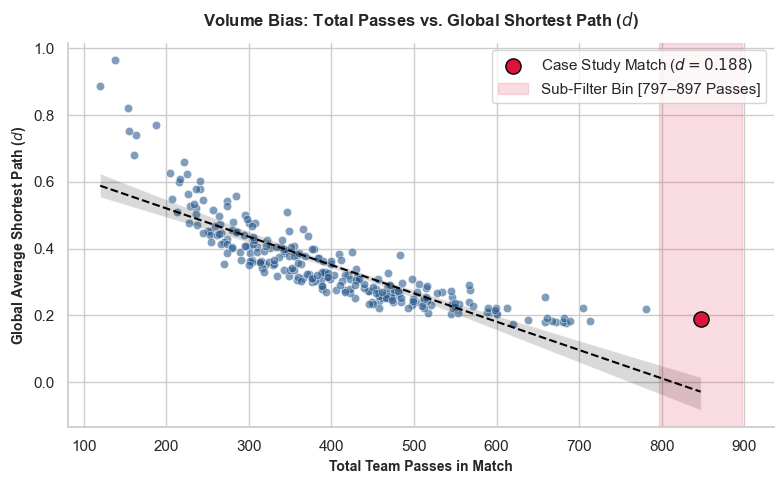

In [215]:
# ==============================================================================
# EXECUTION
# ==============================================================================
plot_volume_bias_scatterplot(
    league_df_wsl,
    case_study_team="Arsenal WFC",
    case_study_passes=847,
    bin_width=50,
)

#### Sparsity Trap Summary Table

In [225]:
import pandas as pd


def generate_sparsity_trap_report(
    league_df,
    case_study_team="Arsenal WFC",
    case_study_passes=847,
    bin_width=50,
):
    """Generates a text report and returns a summary DataFrame of matches in the sub-filtering bin

    to demonstrate the Data Sparsity Trap.
    """
    lower_bound = case_study_passes - bin_width
    upper_bound = case_study_passes + bin_width

    # Filter matches falling within the pass volume bin
    bin_df = league_df[
        (league_df["Total_Passes"] >= lower_bound)
        & (league_df["Total_Passes"] <= upper_bound)
    ].sort_values(by="Total_Passes", ascending=False)

    case_study_row = league_df[
        (league_df["Team"] == case_study_team)
        & (league_df["Total_Passes"] == case_study_passes)
    ]
    case_study_d = (
        case_study_row["d_global"].values[0]
        if not case_study_row.empty
        else 0.1884
    )

    # Print Summary Report to Console
    print("=" * 80)
    print("EMPIRICAL BASELINE DIAGNOSTIC REPORT: DATA SPARSITY TRAP")
    print("=" * 80)
    print(f"Total League Sample Size (N): {len(league_df)} team-matches")
    print(
        f"League Mean Pass Volume:     "
        f" {league_df['Total_Passes'].mean():.2f} ±"
        f" {league_df['Total_Passes'].std():.2f} passes"
    )
    print(
        f"League Mean Shortest Path:    {league_df['d_global'].mean():.4f} units"
    )
    print("-" * 80)
    print(
        f"Case Study Match:            {case_study_team} ({case_study_passes}"
        f" Passes, d = {case_study_d:.4f})"
    )
    print(
        f"Tactical Sub-Filter Range:   [{lower_bound} to {upper_bound} passes]"
    )
    print(
        f"Filtered Sample Size (n):    {len(bin_df)} matches ("
        f"{(len(bin_df) / len(league_df)) * 100:.2f}% of dataset)"
    )
    print(f"Unique Teams in Bin:         {bin_df['Team'].nunique()}")
    print("=" * 80)

    # Format return table for notebook visualization
    summary_table = bin_df.copy()
    summary_table.columns = [
        "Match ID",
        "Team Name",
        "Total Passes",
        "Shortest Path (d)",
    ]
    summary_table["Shortest Path (d)"] = summary_table[
        "Shortest Path (d)"
    ].round(4)

    return summary_table.reset_index(drop=True)

In [226]:
# ==============================================================================
# EXECUTION
# ==============================================================================
bin_summary_table = generate_sparsity_trap_report(
    league_df_wsl,
    case_study_team="Arsenal WFC",
    case_study_passes=847,
    bin_width=50,
)

# Render formatted table in Jupyter Notebook
bin_summary_table.style.set_caption(
    "Empirical Matches Retained After Volume Sub-Filtering"
)

EMPIRICAL BASELINE DIAGNOSTIC REPORT: DATA SPARSITY TRAP
Total League Sample Size (N): 264 team-matches
League Mean Pass Volume:      398.72 ± 126.06 passes
League Mean Shortest Path:    0.3521 units
--------------------------------------------------------------------------------
Case Study Match:            Arsenal WFC (847 Passes, d = 0.1884)
Tactical Sub-Filter Range:   [797 to 897 passes]
Filtered Sample Size (n):    1 matches (0.38% of dataset)
Unique Teams in Bin:         1


,Match ID,Team Name,Total Passes,Shortest Path (d)
0,3913160,Arsenal WFC,847,0.188400


#### Pass Binning

In [223]:
import pandas as pd


def count_matches_in_range(league_df, lower_bound, upper_bound):
    """Returns the count of team-matches falling within [lower_bound, upper_bound)."""
    # Includes lower_bound, excludes upper_bound (standard half-open interval)
    condition = (league_df["Total_Passes"] >= lower_bound) & (
        league_df["Total_Passes"] < upper_bound
    )
    return int(condition.sum())


def generate_pass_volume_bin_table(league_df, bin_step=100, max_passes=1000):
    """Iterates through pass volume ranges of size bin_step and compiles a summary table."""
    bin_data = []

    # Loop from 0 to 1000 in steps of 100
    for lower in range(0, max_passes, bin_step):
        upper = lower + bin_step
        count = count_matches_in_range(league_df, lower, upper)
        percentage = (count / len(league_df)) * 100 if len(league_df) > 0 else 0

        bin_data.append({
            "Pass Range": f"{lower}–{upper - 1}",
            "Match Count (n)": count,
            "Percentage (%)": f"{percentage:.2f}%",
        })

    # Convert to DataFrame
    table_df = pd.DataFrame(bin_data)
    return table_df

In [224]:
# ==============================================================================
# EXECUTION
# ==============================================================================
# Generate the 100-pass bin distribution table
pass_bin_table = generate_pass_volume_bin_table(
    league_df_wsl, bin_step=100, max_passes=1000
)

# Display table
pass_bin_table

,Pass Range,Match Count (n),Percentage (%)
0,0–99,0,0.00%
1,100–199,7,2.65%
2,200–299,52,19.70%
3,300–399,88,33.33%
4,400–499,66,25.00%
5,500–599,34,12.88%
6,600–699,13,4.92%
7,700–799,3,1.14%
8,800–899,1,0.38%
9,900–999,0,0.00%


### Traditional Nulls

#### ER Null Model

##### ER Function

In [283]:
import networkx as nx
import numpy as np


def generate_erdos_renyi_null_incremental(G_empirical, seed=None):
    """Generates an Erdős–Rényi G(N, p) directed null network by preserving node

    attributes (including spatial position) and total pass volume, constructing
    the new network by adding 1 pass at a time.

    Parameters:
        G_empirical (nx.DiGraph): Empirical weighted directed passing network.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        G_null (nx.DiGraph): New synthetic Erdős–Rényi null network.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1. Initialize empty DiGraph and copy exact nodes with all attributes (x, y, pos, names)
    G_null = nx.DiGraph()
    G_null.add_nodes_from(G_empirical.nodes(data=True))

    nodes = list(G_empirical.nodes())
    N = len(nodes)

    if N < 2:
        return G_null

    # 2. Extract empirical invariants
    total_volume = int(
        sum(
            data.get("weight", 1) for _, _, data in G_empirical.edges(data=True)
        )
    )
    num_empirical_edges = G_empirical.number_of_edges()

    # Calculate connection probability p = empirical_edges / max_possible_edges
    max_possible_edges = N * (N - 1)
    p = (
        num_empirical_edges / max_possible_edges
        if max_possible_edges > 0
        else 0
    )

    # 3. Determine active directed pairs via independent Bernoulli trials (G(N, p) skeleton)
    all_possible_pairs = [
        (u, v) for i, u in enumerate(nodes) for j, v in enumerate(nodes) if i != j
    ]
    active_edges = [
        pair for pair in all_possible_pairs if np.random.binomial(1, p) == 1
    ]

    # Safeguard: if Bernoulli trials yield 0 edges, fallback to selecting 1 random pair
    if not active_edges and all_possible_pairs:
        active_edges = [
            all_possible_pairs[np.random.choice(len(all_possible_pairs))]
        ]

    # 4. Build up the network allocating 1 pass at a time
    edge_weights = {pair: 0 for pair in active_edges}
    num_active = len(active_edges)

    for _ in range(total_volume):
        # Pick 1 random active channel with equal probability
        chosen_index = np.random.randint(0, num_active)
        chosen_pair = active_edges[chosen_index]

        # Increment pass connection count by 1
        edge_weights[chosen_pair] += 1

    # 5. Add edges receiving > 0 passes to the new network
    for (u, v), weight in edge_weights.items():
        if weight > 0:
            G_null.add_edge(u, v, weight=weight)

    return G_null

##### ER Network

Nodes Preserved: 11 (Attributes intact: {'player_id': 5000, 'position': 'Left Back', 'pos': (62.29526748971194, 15.572530864197532), 'x': 62.29526748971194, 'y': 15.572530864197532})
Total Passes:    720


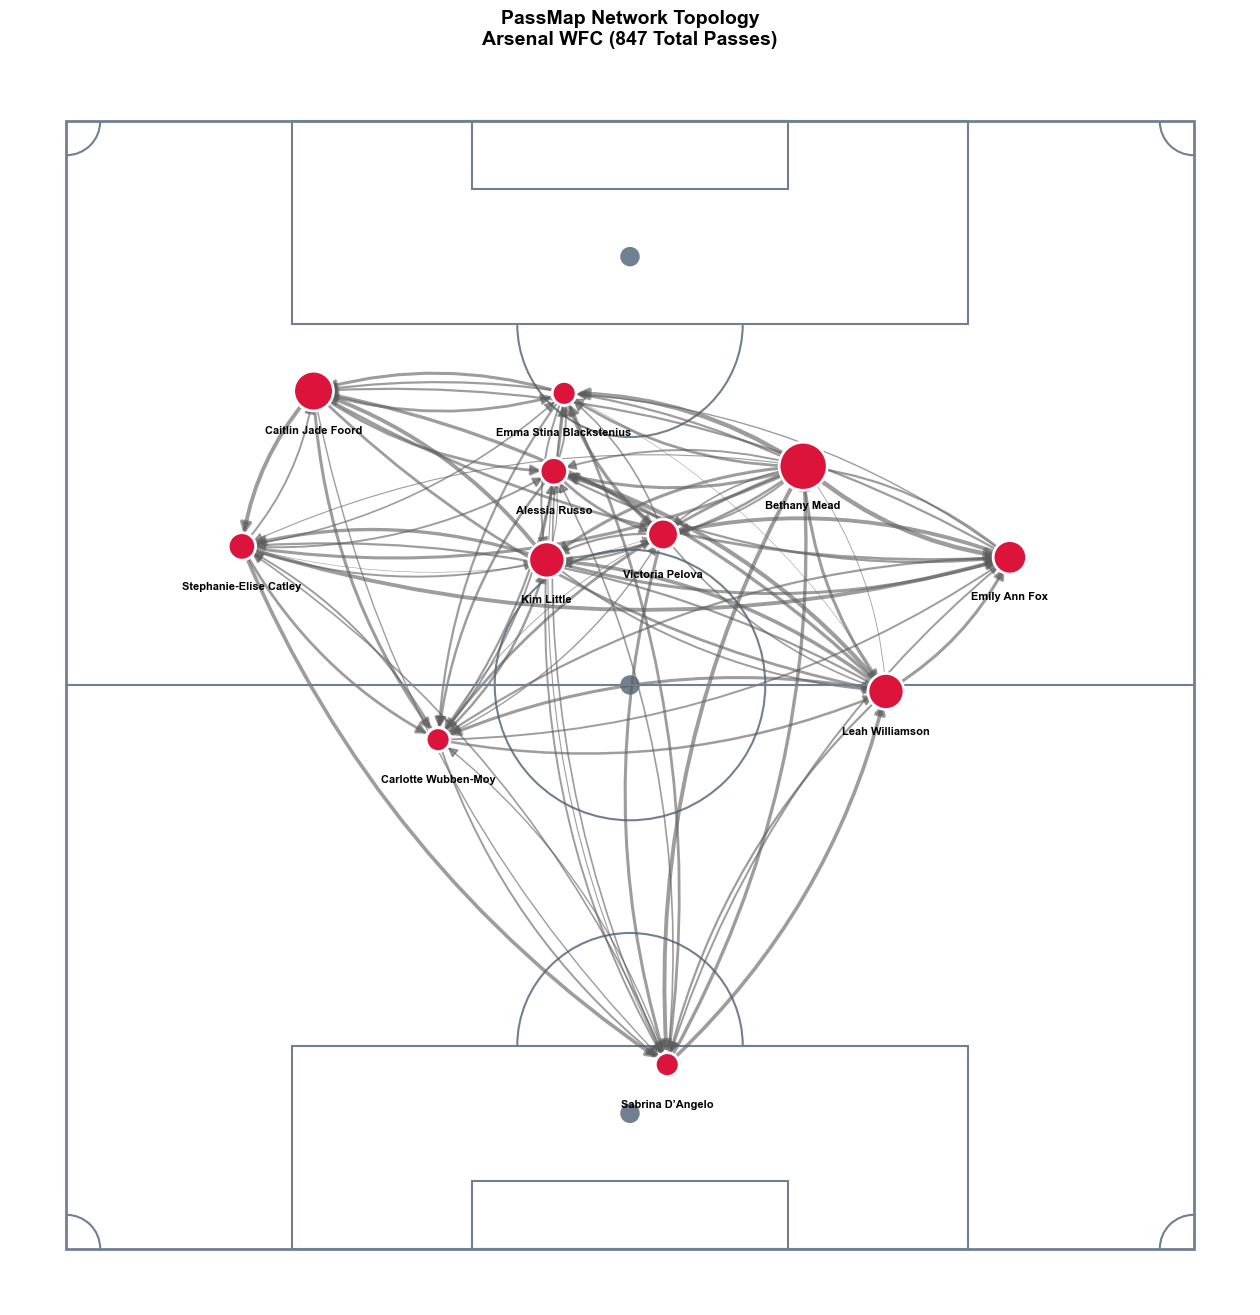

In [285]:
# ==============================================================================
# EXECUTION & VERIFICATION
# ==============================================================================
G_null_er = generate_erdos_renyi_null_incremental(G_arsenal, seed=151)

# Verify invariants:
print(f"Nodes Preserved: {len(G_null_er.nodes())} (Attributes intact: {G_null_er.nodes[list(G_null_er.nodes())[0]]})")
print(f"Total Passes:    {sum(d['weight'] for _, _, d in G_null_er.edges(data=True))}")

# 1. Compute betweenness scores
betweenness_df_arsenal_ER, betweenness_dict_arsenal_ER = calculate_betweenness_centrality(G_null_er)

# 2. Plot passmap with nodes sized by betweenness centrality
plot_passmap_on_pitch(
    G=G_null_er, 
    team_name=highest_pass_match[2], 
    total_passes=highest_pass_match[3],
    node_scores=betweenness_dict_arsenal_ER,
)

##### Null ER Degree Analysis

In [264]:
# =============================================================================
# EXECUTION FOR SECTION 4.1 CASE STUDY (Arsenal WFC)
# =============================================================================

# Analyze graph using the integrated function
player_df_er, macro_stats_er, top_hubs_df_Er = analyze_degree_and_heterogeneity(G_null_er, top_n_hubs=5)

# 1. Player-Level Table
print("\n" + "="*90)
print("#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df_er.to_string())

# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats_er.items():
    print(f"{metric_name:<45}: {val:.4f}")

# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df_Er.to_string(index=False))


#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)
                                          Position  k_in (In-Degree)  k_out (Out-Degree)  s_in (Passes Rec.)  s_out (Passes Comp.)  Total Volume (s_tot)  Net Flow (Δs_i)  Pass Ratio (s_out / s_in)
Player                                                                                                                                                                                              
Bethany Mead                            Right Wing                 9                   9                  71                    80                   151                9                       1.13
Victoria Pelova           Right Defensive Midfield                 9                   8                  78                    66                   144              -12                       0.85
Stephanie-Elise Catley                   Left Back                 8                   8                  75                    68      

##### Null ER Triads

In [267]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

global_I_trans_ER, triad_df_trans_ER, active_triads_ER = calculate_transitive_triad_intensity(G_null_er)

print("\n" + "="*80)
print("Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC")
print("="*80)
print(f"Global Team Transitive Triad Intensity (I_team): {global_I_trans_ER:.2f} pass units")

print("\n" + "="*80)
print("Player-Level Transitive Triad Summary (Ranked by I_transitive)")
print("="*80)
print(triad_df_trans_ER.to_string())

print("\n" + "="*80)
print("Top 10 Active Transitive Triads")
print("="*80)

top_triads_summary_ER = []
for idx, t in enumerate(active_triads_ER[:10], start=1):
    p1, p2, p3 = t["players"]
    top_triads_summary_ER.append({
        "Rank": idx,
        "Player 1 (Origin/Target)": p1,
        "Player 2 (Intermediate)": p2,
        "Player 3 (Target/Origin)": p3,
        "Total Capacity (Pass Units)": round(t["total_capacity"], 2)
    })

top_triads_df_ER = pd.DataFrame(top_triads_summary_ER).set_index("Rank")
print(top_triads_df_ER.to_string())


Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC
Global Team Transitive Triad Intensity (I_team): 844.36 pass units

Player-Level Transitive Triad Summary (Ranked by I_transitive)
                                          Position  Transitive Triad Intensity (I_transitive)
Player                                                                                       
Leah Williamson                  Right Center Back                                     1033.0
Sabrina D’Angelo                        Goalkeeper                                      991.0
Caitlin Jade Foord                       Left Wing                                      960.0
Bethany Mead                            Right Wing                                      944.0
Victoria Pelova           Right Defensive Midfield                                      942.0
Stephanie-Elise Catley                   Left Back                                      888.0
Alessia Russo            Center Attacking M

#### Rewire Null

##### Computation Function

In [296]:
import copy
import networkx as nx
import numpy as np

def generate_whole_edge_rewired_null(
    G_empirical, n_swaps_factor=10, max_attempts=100000, seed=None
):
    """Generates a Directed Whole-Edge Degree-Preserving Rewired Null Model

    (Configuration Model).

    Swaps entire weighted edge vectors as discrete units to preserve each
    player's exact directed degree sequences (k_in and k_out).

    Parameters:
        G_empirical (nx.DiGraph): Empirical weighted directed passing network.
        n_swaps_factor (int): Multiplier for edge count to set target swap
          attempts.
        max_attempts (int): Safeguard iteration limit for swap attempts.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        G_null (nx.DiGraph): Synthetic degree-preserving rewired null network.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1. Initialize output graph with exact nodes and spatial attributes (x, y, pos)
    G_null = nx.DiGraph()
    G_null.add_nodes_from(G_empirical.nodes(data=True))

    # 2. Extract edge list with full weights intact
    edges = list(G_empirical.edges(data=True))
    if len(edges) < 2:
        return G_empirical.copy()

    # Format: [(u1, v1, weight1), (u2, v2, weight2), ...]
    edge_list = [(u, v, d.get("weight", 1)) for u, v, d in edges]
    num_edges = len(edge_list)
    target_swaps = num_edges * n_swaps_factor

    # Fast O(1) set lookup for active directed pairs to prevent self-loops and multi-edges
    adj_set = set((u, v) for u, v, _ in edge_list)

    successful_swaps = 0
    attempts = 0

    # 3. Perform 2-edge directed swaps on entire edge channels
    while successful_swaps < target_swaps and attempts < max_attempts:
        attempts += 1

        # Select two distinct directed edge channels at random: (A -> B) and (C -> D)
        idx1, idx2 = np.random.choice(num_edges, size=2, replace=False)
        u1, v1, w1 = edge_list[idx1]
        u2, v2, w2 = edge_list[idx2]

        # Proposed new directed channels: (A -> D) and (C -> B)
        new_edge1 = (u1, v2)
        new_edge2 = (u2, v1)

        # Validity Checks:
        # 1. No self-loops (u1 != v2 and u2 != v1)
        # 2. No duplicate multi-edges (new pairs must not already exist in adj_set)
        if u1 != v2 and u2 != v1:
            valid_swap1 = (new_edge1 not in adj_set) or (new_edge1 == (u1, v1))
            valid_swap2 = (new_edge2 not in adj_set) or (new_edge2 == (u2, v2))

            if valid_swap1 and valid_swap2:
                # Remove original edges from active set
                adj_set.remove((u1, v1))
                adj_set.remove((u2, v2))

                # Add new rewired edges to active set
                adj_set.add(new_edge1)
                adj_set.add(new_edge2)

                # Swap destination endpoints while carrying full accumulated weights
                edge_list[idx1] = (u1, v2, w1)
                edge_list[idx2] = (u2, v1, w2)

                successful_swaps += 1

    # 4. Populate rewired DiGraph with swapped weighted edges
    for u, v, weight in edge_list:
        G_null.add_edge(u, v, weight=weight)

    return G_null


# ==============================================================================
# VERIFICATION EXECUTION
# ==============================================================================
G_null_rewired = generate_whole_edge_rewired_null(G_arsenal, seed=42)

# Verify degree sequence preservation:
emp_in_deg = [d for n, d in G_arsenal.in_degree()]
null_in_deg = [d for n, d in G_null_rewired.in_degree()]
print(f"In-Degree Sequence Preserved: {emp_in_deg == null_in_deg}")

In-Degree Sequence Preserved: True


##### Network Plot (w/ Betweeness)

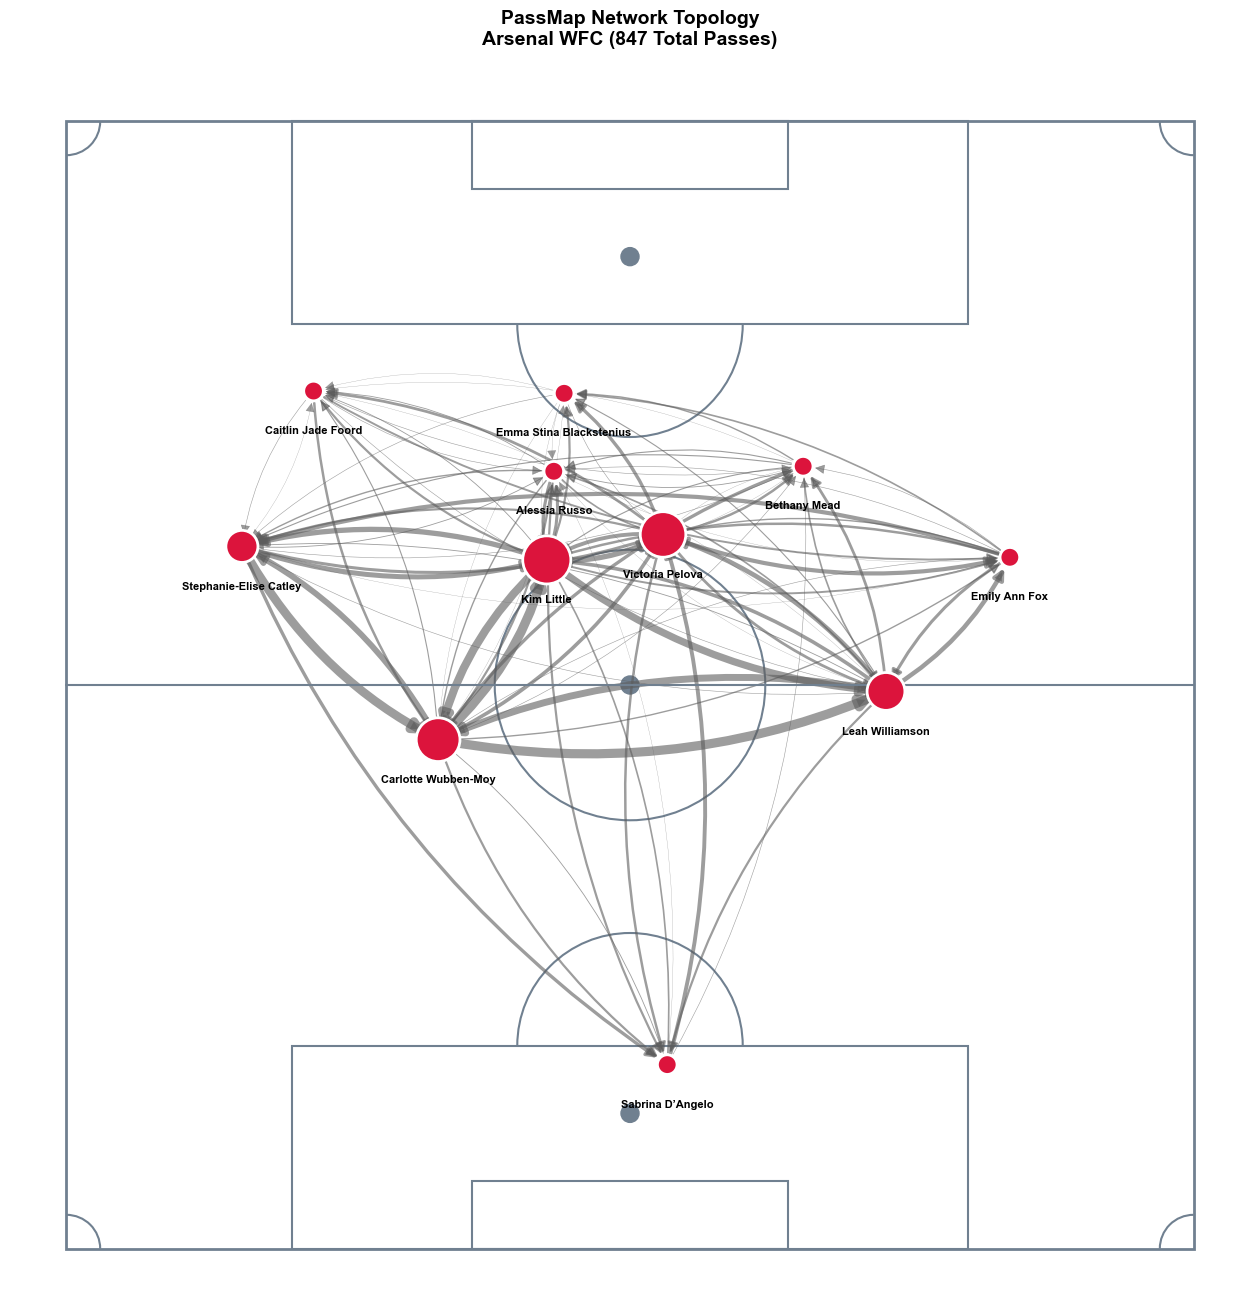

In [297]:
# 1. Compute betweenness scores
betweenness_df_arsenal_rewired, betweenness_dict_arsenal_rewired = calculate_betweenness_centrality(G_null_rewired)

# 2. Plot passmap with nodes sized by betweenness centrality
plot_passmap_on_pitch(
    G=G_null_rewired, 
    team_name=highest_pass_match[2], 
    total_passes=highest_pass_match[3],
    node_scores=betweenness_dict_arsenal_rewired,
)

##### Degree Analysis

In [298]:
# =============================================================================
# EXECUTION FOR SECTION 4.1 CASE STUDY (Arsenal WFC)
# =============================================================================

# Analyze graph using the integrated function
player_df_rewired, macro_stats_rewired, top_hubs_df_rewired = analyze_degree_and_heterogeneity(G_null_rewired, top_n_hubs=5)

# 1. Player-Level Table
print("\n" + "="*90)
print("#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df_rewired.to_string())

# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats_rewired.items():
    print(f"{metric_name:<45}: {val:.4f}")

# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df_rewired.to_string(index=False))


#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)
                                          Position  k_in (In-Degree)  k_out (Out-Degree)  s_in (Passes Rec.)  s_out (Passes Comp.)  Total Volume (s_tot)  Net Flow (Δs_i)  Pass Ratio (s_out / s_in)
Player                                                                                                                                                                                              
Carlotte Wubben-Moy               Left Center Back                 9                  10                 117                   128                   245               11                       1.09
Kim Little                 Left Defensive Midfield                10                   9                 117                   123                   240                6                       1.05
Leah Williamson                  Right Center Back                 8                  10                  91                   103      

##### Clustering Analysis

In [299]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

global_I_trans_rewired, triad_df_trans_rewired, active_triads_rewired = calculate_transitive_triad_intensity(G_null_rewired)

print("\n" + "="*80)
print("Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC")
print("="*80)
print(f"Global Team Transitive Triad Intensity (I_team): {global_I_trans_rewired:.2f} pass units")

print("\n" + "="*80)
print("Player-Level Transitive Triad Summary (Ranked by I_transitive)")
print("="*80)
print(triad_df_trans_rewired.to_string())

print("\n" + "="*80)
print("Top 10 Active Transitive Triads")
print("="*80)

top_triads_summary_rewired = []
for idx, t in enumerate(active_triads_rewired[:10], start=1):
    p1, p2, p3 = t["players"]
    top_triads_summary_rewired.append({
        "Rank": idx,
        "Player 1 (Origin/Target)": p1,
        "Player 2 (Intermediate)": p2,
        "Player 3 (Target/Origin)": p3,
        "Total Capacity (Pass Units)": round(t["total_capacity"], 2)
    })

top_triads_df_rewired = pd.DataFrame(top_triads_summary_rewired).set_index("Rank")
print(top_triads_df_rewired.to_string())


Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC
Global Team Transitive Triad Intensity (I_team): 513.00 pass units

Player-Level Transitive Triad Summary (Ranked by I_transitive)
                                          Position  Transitive Triad Intensity (I_transitive)
Player                                                                                       
Kim Little                 Left Defensive Midfield                                      943.0
Carlotte Wubben-Moy               Left Center Back                                      807.0
Leah Williamson                  Right Center Back                                      728.0
Victoria Pelova           Right Defensive Midfield                                      696.0
Stephanie-Elise Catley                   Left Back                                      613.0
Alessia Russo            Center Attacking Midfield                                      435.0
Emily Ann Fox                           Rig

### Implementation

#### Binning Function

In [569]:
import numpy as np
import pandas as pd


def bin_coordinates(x, y, grid_size=(10, 10)):
    """Normalizes StatsBomb coordinates (120x80) to a 0-100 scale

    and assigns them directly to matrix bin indices (row, col).

    Parameters:
        x (float or np.ndarray): Raw x-coordinate in [0, 120].
        y (float or np.ndarray): Raw y-coordinate in [0, 80].
        grid_size (tuple): Dimensions of the matrix grid (n_rows, n_cols).
          Default: (10, 10).

    Returns:
        tuple or list of tuples: (row_idx, col_idx) matrix coordinates
        (0-indexed).

        (vertical, horiztonal)
    """
    n_rows, n_cols = grid_size

    # 1. Normalize StatsBomb coordinates to 0-100 scale
    x_norm = (np.asarray(x) / 120.0) * 100.0
    y_norm = (np.asarray(y) / 80.0) * 100.0

    # 2. Calculate bin sizes on the 0-100 scale (e.g., 10.0 for a 10x10 grid)
    bin_size_x = 100.0 / n_cols
    bin_size_y = 100.0 / n_rows

    # 3. Map to matrix row (y-axis) and column (x-axis)
    rows = np.clip((x_norm // bin_size_x).astype(int), 0, n_cols - 1)
    cols = np.clip((y_norm // bin_size_y).astype(int), 0, n_rows - 1)

    # print(x,y,x_norm,y_norm,bin_size_x,bin_size_y,rows,cols)

    if np.isscalar(x) and np.isscalar(y):
        return int(rows), int(cols)

    return list(zip(rows, cols))

# ==============================================================================
# EXAMPLE USAGE WITH STATSBOMB DATA
# ==============================================================================
# 1. Single Pass Coordinates (e.g., Penalty spot area: x=108, y=40)
# [7.8, 7.0]	(6.5, 8.75)	
x,y = 6.5,8.75
row, col = bin_coordinates(x,y)
print(f"StatsBomb Pass ({x}, {y}) -> Matrix Bin: Row {row}, Col {col}")

# 2. Applied directly to StatsBomb DataFrame
passes_df = pd.DataFrame({"x": [15.0, 60.0, 110.0], "y": [40.0, 20.0, 75.0]})

# Vectorized bin assignment
passes_df["bin"] = bin_coordinates(passes_df["x"].values, passes_df["y"].values)
print("\nBinned StatsBomb Event Data:")
print(passes_df)

StatsBomb Pass (6.5, 8.75) -> Matrix Bin: Row 0, Col 1

Binned StatsBomb Event Data:
       x     y     bin
0   15.0  40.0  (1, 5)
1   60.0  20.0  (5, 2)
2  110.0  75.0  (9, 9)


#### Grid Plot

##### Grid Plot Function

In [403]:
import matplotlib.pyplot as plt


def draw_pitch_with_grid(
    original_pitch_func,
    ax=None,
    grid_size=(10, 10),
    grid_color="#888888",
    grid_linestyle="--",
    grid_alpha=0.5,
    show_bin_labels=False,
    **kwargs,
):
    """Wraps any original pitch-drawing function and overlays a spatial grid

    without modifying the original function.
    """
    # 1. Call the original function (it will create a figure/axis if ax is None)
    ax = original_pitch_func(ax=ax, **kwargs)

    # 2. Extract axis from the returned ax object
    if ax is None:
        return ax

    n_rows, n_cols = grid_size
    x_step = 100.0 / n_cols
    y_step = 100.0 / n_rows

    # 3. Draw Vertical Grid Lines (Columns along X)
    for c in range(1, n_cols):
        x = c * x_step
        ax.plot(
            [x, x],
            [0, 100],
            color=grid_color,
            linestyle=grid_linestyle,
            alpha=grid_alpha,
            lw=1,
            zorder=1,
        )

    # 4. Draw Horizontal Grid Lines (Rows along Y)
    for r in range(1, n_rows):
        y = r * y_step
        ax.plot(
            [0, 100],
            [y, y],
            color=grid_color,
            linestyle=grid_linestyle,
            alpha=grid_alpha,
            lw=1,
            zorder=1,
        )

    # 5. Optional: Label matrix (row, col) indices
    if show_bin_labels:
        for r in range(n_rows):
            for c in range(n_cols):
                center_x = (c + 0.5) * x_step
                center_y = (r + 0.5) * y_step
                ax.text(
                    center_x,
                    center_y,
                    f"({r},{c})",
                    color=grid_color,
                    fontsize=7,
                    ha="center",
                    va="center",
                    alpha=0.7,
                    zorder=2,
                )

    return ax

##### Grid Plot

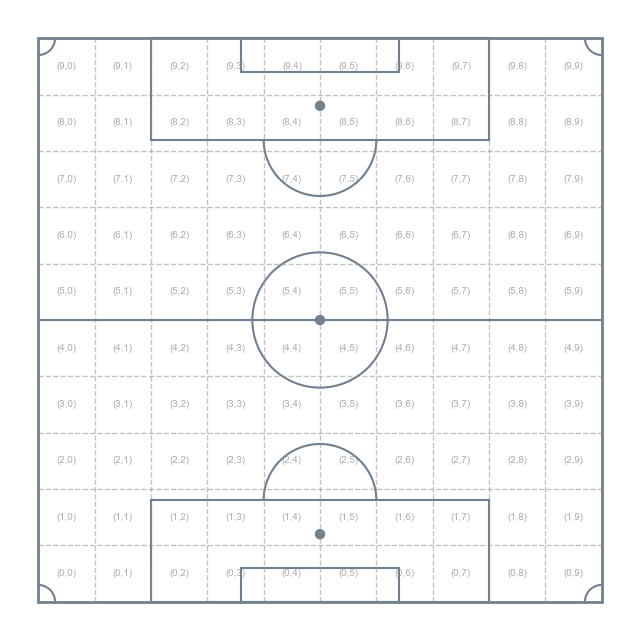

In [404]:
# ==============================================================================
# EXAMPLE USAGE (Assuming your original draw_vertical_pitch is already defined)
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 11))
draw_pitch_with_grid(
    original_pitch_func=draw_vertical_pitch,
    ax=ax,
    grid_size=(10, 10),
    show_bin_labels=True
)
plt.show()

##### Grid Plot w/ Raw Passes

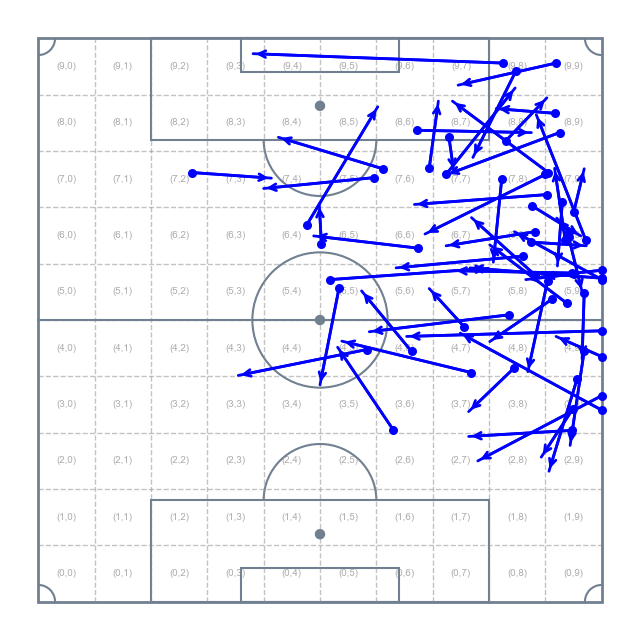

In [405]:
# ==============================================================================
# EXAMPLE USAGE (Assuming your original draw_vertical_pitch is already defined)
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 11))
draw_pitch_with_grid(
    original_pitch_func=draw_vertical_pitch,
    ax=ax,
    grid_size=(10, 10),
    show_bin_labels=True
)

events = sb.events(match_id=3913160)

# 2. Extract Successful Passes
_team_passes = events[
    (events['team'] == 'Arsenal WFC') & 
    (events['type'] == 'Pass') & 
    (events['pass_outcome'].isna()) & # successful pass
    (events['player'] == 'Emily Ann Fox')
]

passes = _team_passes[['location', 'pass_end_location']].apply(
    lambda row: [
        scale_coord(row['location'][1], axis='y'), scale_coord(row['location'][0], axis='x'), 
        scale_coord(row['pass_end_location'][1], axis='y'), scale_coord(row['pass_end_location'][0], axis='x')
    ], 
    axis=1
).tolist()

# 4. Plot passes over the pitch
for start_x, start_y, end_x, end_y in passes:
    # Plot line for the pass trajectory
    ax.plot([start_x, end_x], [start_y, end_y], color='blue', linewidth=2, zorder=3)
    
    # Plot start point
    ax.scatter(start_x, start_y, color='blue', s=30, zorder=4)
    
    # Optional: Add arrow to indicate direction
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(arrowstyle="->", color='blue', lw=2),
        zorder=3
    )

plt.show()

#### Pass Dataset

##### Helper Functions

In [587]:
def bin_pass_dataset(pass_dataset):
    
    # bin the START location pass:
    pass_dataset['start_loc_coord'] = pass_dataset['location']

    pass_dataset['scaled_start_loc_coord'] = pass_dataset['location'].apply(
    lambda loc:(
        round(scale_coord(loc[0], axis='x'), 2), 
        round(scale_coord(loc[1], axis='y'), 2) 
        if isinstance(loc, (tuple, list)) else np.nan)
    )

    pass_dataset['start_loc_bin'] = pass_dataset['location'].apply(
        lambda loc: 
        bin_coordinates(loc[0], loc[1]) 
        if isinstance(loc, (tuple, list)) 
        else np.nan
    )

    # bin the PASS END location:
    pass_dataset['end_loc_coord'] = pass_dataset['pass_end_location']

    pass_dataset['scaled_end_loc_coord'] = pass_dataset['pass_end_location'].apply(
        lambda loc:(
            round(scale_coord(loc[0], axis='x'), 2), 
            round(scale_coord(loc[1], axis='y'), 2) 
            if isinstance(loc, (tuple, list)) else np.nan)
        )

    pass_dataset['end_loc_bin'] = pass_dataset['pass_end_location'].apply(
        lambda loc: 
        bin_coordinates(loc[0], loc[1]) 
        if isinstance(loc, (tuple, list)) 
        else np.nan
    )

    return pass_dataset

##### Construct Pass Data

In [ ]:
import pandas as pd


def extract_passes_with_recipient_position(events_df):
    """
    Extracts successful passes and appends the recipient's starting position for each match.
    Enforces strict 1-to-1 merge validation to prevent duplicate pass rows.
    """
    # 1. Fetch lineup data to exact player postion lookup
    unique_matches = events_df['match_id'].unique()
    all_positions = []

    for match_id in unique_matches:
        match_lineups = sb.lineups(match_id=match_id)
        
        # sb.lineups returns a dictionary mapping team names to player DataFrames
        for team_name, lineup_df in match_lineups.items():
            for _, player in lineup_df.iterrows():
                player_id = player['player_id']
                positions = player.get('positions', [])
                
                # Extract the first logged position (starter role or role when subbed on)
                if isinstance(positions, list) and len(positions) > 0:
                    first_pos = positions[0].get('position')
                    if first_pos:
                        all_positions.append({
                            'match_id': match_id,
                            'pass_recipient_id': player_id,
                            'recipient_position': first_pos
                        })

    # 2. Deduplicate lookup table (enforces 1 position per player per match)
    lineup_lookup = pd.DataFrame(all_positions).drop_duplicates(
        subset=['match_id', 'pass_recipient_id'], keep='first'
    )

    # 3. Filter for successful passes
    passes = events_df[
        (events_df['type'] == 'Pass') & 
        (events_df['pass_outcome'].isna())
    ].copy()

    # 4. Retain required columns
    required_cols = [
        'id', 'match_id', 'type', 'location', 'possession_team',
        'player', 'position', 'possession_team_id', 'pass_end_location',
        'pass_recipient', 'pass_recipient_id', 'pass_length'
    ]
    available_cols = [c for c in required_cols if c in passes.columns]
    passes = passes[available_cols]

    # 5. Merge with strict duplicate checking
    passes = passes.merge(
        lineup_lookup,
        on=['match_id', 'pass_recipient_id'],
        how='left',
        validate='many_to_one'  # Raises MergeError if lookup contains non-unique keys
    )

    # 6. Condense Positions
    passes['recipient_position_11'] = passes['recipient_position'].apply(map_position)

    return bin_pass_dataset(passes)


In [589]:
# ==============================================================================
# EXAMPLE USAGE
# ==============================================================================
COMPETITION_ID = 37
SEASON_ID = 281

matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
pass_match_records = []

for idx, match in matches_df.iterrows():
    m_id = match['match_id']
    
    # 1. Fetch match events
    events_df = sb.events(match_id=m_id)
    
    # 2. Extract and enrich passes
    match_passes_df = extract_passes_with_recipient_position(events_df)
    
    # 3. Append to records list
    pass_match_records.append(match_passes_df)
    print(f"Match {m_id}: Extracted {len(match_passes_df)} passes.")

# Combine all matches into a single, master DataFrame
all_passes_df = pd.concat(pass_match_records, ignore_index=True)
print(f"\nTotal passes compiled across {len(matches_df)} matches: {len(all_passes_df):,}")

Match 3913082: Extracted 661 passes.
Match 3913155: Extracted 797 passes.
Match 3913167: Extracted 869 passes.
Match 3913175: Extracted 790 passes.
Match 3913107: Extracted 873 passes.
Match 3913165: Extracted 754 passes.
Match 3913115: Extracted 702 passes.
Match 3913147: Extracted 851 passes.
Match 3913129: Extracted 807 passes.
Match 3912603: Extracted 847 passes.
Match 3913134: Extracted 846 passes.
Match 3913069: Extracted 933 passes.
Match 3912599: Extracted 686 passes.
Match 3913131: Extracted 763 passes.
Match 3913137: Extracted 682 passes.
Match 3913174: Extracted 876 passes.
Match 3913186: Extracted 692 passes.
Match 3913185: Extracted 916 passes.
Match 3913180: Extracted 820 passes.
Match 3913181: Extracted 855 passes.
Match 3913171: Extracted 821 passes.
Match 3913168: Extracted 954 passes.
Match 3913169: Extracted 836 passes.
Match 3913182: Extracted 820 passes.
Match 3913173: Extracted 680 passes.
Match 3913166: Extracted 823 passes.
Match 3913157: Extracted 626 passes.
M

#### Position Counter

##### Custom Postion Mapper

In [474]:
def map_position(position_name):
    """Maps a single StatsBomb position string to its 11-class taxonomy equivalent.

    Returns None if the position is unrecognized or NaN.
    """
    return POSITION_MAP_11.get(position_name, None)

In [487]:
# Mapping StatsBomb's 25 positions to 11 Core Functional Classes
POSITION_MAP_11 = {
    # Center Backs
    "Center Back": "CB",
    "Left Center Back": "CB",
    "Right Center Back": "CB",
    # Goalkeeper
    "Goalkeeper": "GK",
    # Fullbacks/Wingbacks (Left)
    "Left Back": "LB",
    "Left Wing Back": "LB",
    # Fullbacks/Wingbacks (Right)
    "Right Back": "RB",
    "Right Wing Back": "RB",
    # Defensive/Central Midfielders
    "Left Defensive Midfield": "DM",
    "Center Defensive Midfield": "DM",
    "Right Defensive Midfield": "DM",
    # Central Midfielders
    "Left Center Midfield": "CM",
    "Right Center Midfield": "CM",
    # Attacking Midfielders
    "Center Attacking Midfield": "CAM",
    "Right Attacking Midfield": "CAM",
    "Left Attacking Midfield": "CAM",
    # Strikers/Forwards
    "Center Forward": "ST",
    "Left Center Forward": "ST",
    "Right Center Forward": "ST",
    # Wide Left
    "Left Wing": "LM",
    "Left Midfield": "LM",
    # Wide Right
    "Right Wing": "RM",
    "Right Midfield": "RM",
}

In [490]:
from collections import defaultdict

# Reverse mapping: 11-Class Role -> List of StatsBomb Positions
REVERSE_POSITION_MAP_11 = defaultdict(list)

for statsbomb_pos, core_class in POSITION_MAP_11.items():
    REVERSE_POSITION_MAP_11[core_class].append(statsbomb_pos)

# Convert back to standard dict if preferred
REVERSE_POSITION_MAP_11 = dict(REVERSE_POSITION_MAP_11)
REVERSE_POSITION_MAP_11

{'CB': ['Center Back', 'Left Center Back', 'Right Center Back'],
 'GK': ['Goalkeeper'],
 'LB': ['Left Back', 'Left Wing Back'],
 'RB': ['Right Back', 'Right Wing Back'],
 'DM': ['Left Defensive Midfield',
  'Center Defensive Midfield',
  'Right Defensive Midfield'],
 'CM': ['Left Center Midfield', 'Right Center Midfield'],
 'CAM': ['Center Attacking Midfield',
  'Right Attacking Midfield',
  'Left Attacking Midfield'],
 'ST': ['Center Forward', 'Left Center Forward', 'Right Center Forward'],
 'LM': ['Left Wing', 'Left Midfield'],
 'RM': ['Right Wing', 'Right Midfield']}

##### Base Position

In [484]:
import pandas as pd


def get_recipient_position_counts(pass_df, mapped=False):
    """Returns a DataFrame containing recipient positions and their pass counts."""

    if mapped:
        counts_df = (
        pass_df["recipient_position_11"]
        .value_counts(dropna=False)
        .reset_index()
    )
        counts_df.columns = ["recipient_position_11", "count"]
    else:
        counts_df = (
        pass_df["recipient_position"]
        .value_counts(dropna=False)
        .reset_index()
    )
        counts_df.columns = ["recipient_position", "count"]
    return counts_df


# Usage:
position_counts = get_recipient_position_counts(all_passes_df)
print(position_counts)

           recipient_position  count
0            Left Center Back  12908
1           Right Center Back  12231
2                   Left Back   7128
3                  Goalkeeper   7077
4                  Right Back   7023
5     Left Defensive Midfield   6489
6    Right Defensive Midfield   6204
7              Center Forward   5558
8                   Left Wing   5419
9                  Right Wing   5359
10  Center Defensive Midfield   3972
11      Right Center Midfield   3643
12       Left Center Midfield   3620
13  Center Attacking Midfield   3587
14                Center Back   2927
15             Left Wing Back   2677
16            Right Wing Back   2567
17        Left Center Forward   1705
18       Right Center Forward   1654
19             Right Midfield   1496
20              Left Midfield   1445
21   Right Attacking Midfield    300
22    Left Attacking Midfield    273


##### Mapped Position

In [491]:
all_passes_df['recipient_position_11'] = all_passes_df['recipient_position'].apply(
    map_position
)

# Usage:
position_counts = get_recipient_position_counts(all_passes_df, mapped=True)
print(position_counts)

  recipient_position_11  count
0                    CB  28066
1                    DM  16665
2                    LB   9805
3                    RB   9590
4                    ST   8917
5                    CM   7263
6                    GK   7077
7                    LM   6864
8                    RM   6855
9                   CAM   4160


#### Plot Recipient Position on Grid

In [621]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional, Tuple, Callable


def plot_position_reception_diagnostics(
    passes_df: pd.DataFrame,
    target_position: Optional[str] = None,
    pitch_func: Callable = draw_vertical_pitch,
    dot_color: str = "#d90429",
    dot_alpha: float = 0.3,
    sample_size: Optional[int] = None,
    bin_sample: Optional[Tuple[int, int]] = None,
):
    """Plots unbinned pass reception coordinates for a given position over the pitch grid."""
    pos_passes = passes_df.copy()

    if target_position is not None:
        # # 1. Filter passes for target position
        pos_passes['recipient_position_11'] = passes_df['recipient_position'].apply(map_position)
        pos_passes = pos_passes[pos_passes["recipient_position_11"] == target_position]

    # Extract (TEST CODE, REMOVE)
    if bin_sample is not None:
        _x = bin_sample[0]
        _y = bin_sample[1]

        pos_passes = pos_passes[
        (pos_passes['end_loc_bin'].str[0] == _x) & 
        (pos_passes['end_loc_bin'].str[1] == _y)
        ]

    x = [loc[0] if isinstance(loc, (list, tuple)) else np.nan for loc in pos_passes['scaled_end_loc_coord']]
    y = [loc[1] if isinstance(loc, (list, tuple)) else np.nan for loc in pos_passes['scaled_end_loc_coord']]

    # 3. Draw Pitch with Grid
    fig, ax = plt.subplots(figsize=(8, 11))

    draw_vertical_pitch
    pitch_func(
            original_pitch_func=draw_vertical_pitch,
            ax=ax,
            grid_size=(10, 10),
            show_bin_labels=True,
        )
  
    # 4. Scatter Plot
    ax.scatter(
        y, x, # reserved as per statbomb structure
        color=dot_color,
        alpha=dot_alpha,
        s=18,
        edgecolors="none",
        zorder=4,
        label=f"{target_position} Receptions (n={len(pos_passes):,})",
    )

    ax.set_title(
        f"Diagnostic Map: Pass Receptions for [{target_position}]",
        fontsize=14,
        pad=15,
        weight="bold",
    )

    ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9)

    plt.show()

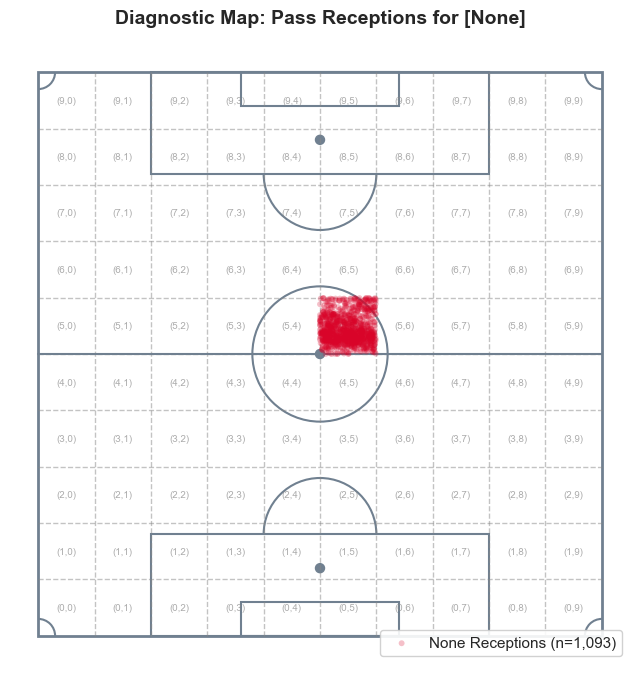

In [622]:
plot_position_reception_diagnostics(
    passes_df=all_passes_df,
    target_position=None,
    pitch_func=draw_pitch_with_grid,
    dot_alpha=0.25,
    bin_sample=(5,5)
)

#### Build Matrices

In [632]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple


def build_prebinned_spatial_probability_model(
    passes_df: pd.DataFrame,
    bin_col: str = "end_loc_bin",
    pos_col: str = "recipient_position_11",
    grid_size: Tuple[int, int] = (10, 10),
    alpha: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, int], Dict[int, str]]:
    """Builds raw frequency and Laplace-smoothed probability tensors from pre-binned pass data.

    Returns:
        prob_tensor (np.ndarray): P(Position | Bin) tensor of shape (10, 10,
          N_pos).
        smoothed_counts (np.ndarray): Frequency tensor with +alpha applied
          directly.
        pos_to_idx (Dict[str, int]): Mapping from position string to tensor
          slice index.
        idx_to_pos (Dict[int, str]): Mapping from tensor slice index back to
          position string.
    """
    n_rows, n_cols = grid_size

    # 1. Clean valid observations
    valid_df = passes_df.dropna(subset=[bin_col, pos_col]).copy()

    # 2. Extract positions and construct index lookup dictionaries
    positions = sorted(valid_df[pos_col].unique().tolist())
    pos_to_idx = {pos: i for i, pos in enumerate(positions)}
    idx_to_pos = {i: pos for i, pos in enumerate(positions)}

    # 3. Initialize raw count matrix
    raw_counts = np.zeros((n_rows, n_cols, len(positions)), dtype=int)

    # 4. Populate raw frequency counts directly from pre-computed tuples
    for _, row in valid_df.iterrows():
        r, c = row[bin_col]
        pos = row[pos_col]
        if pos in pos_to_idx and 0 <= r < n_rows and 0 <= c < n_cols:
            raw_counts[r, c, pos_to_idx[pos]] += 1

    # 5. Apply Laplace Additive Smoothing directly to frequencies
    smoothed_counts = raw_counts.astype(float) + alpha

    # 6. Normalize across positions per bin to form valid probability distribution
    bin_totals = smoothed_counts.sum(axis=-1, keepdims=True)
    prob_tensor = smoothed_counts / bin_totals

    return prob_tensor, smoothed_counts, pos_to_idx, idx_to_pos

In [634]:
# Build the model
prob_tensor, smoothed_counts, pos_to_idx, idx_to_pos = (
    build_prebinned_spatial_probability_model(
        passes_df=all_passes_df,
        bin_col="end_loc_bin",
        pos_col="recipient_position",
        alpha=1.0,
    )
)

In [636]:
pos_to_idx

{'Center Attacking Midfield': 0,
 'Center Back': 1,
 'Center Defensive Midfield': 2,
 'Center Forward': 3,
 'Goalkeeper': 4,
 'Left Attacking Midfield': 5,
 'Left Back': 6,
 'Left Center Back': 7,
 'Left Center Forward': 8,
 'Left Center Midfield': 9,
 'Left Defensive Midfield': 10,
 'Left Midfield': 11,
 'Left Wing': 12,
 'Left Wing Back': 13,
 'Right Attacking Midfield': 14,
 'Right Back': 15,
 'Right Center Back': 16,
 'Right Center Forward': 17,
 'Right Center Midfield': 18,
 'Right Defensive Midfield': 19,
 'Right Midfield': 20,
 'Right Wing': 21,
 'Right Wing Back': 22}

In [635]:
# 1. Extract 2D spatial heatmap matrix for Central Midfielders ('CM')
cm_idx = pos_to_idx["CM"]
cm_probability_surface = prob_tensor[:, :, cm_idx]
cm_frequency_surface = smoothed_counts[:, :, cm_idx]

# 2. Query probability of a specific position in a specific bin cell (e.g., Bin (4, 5))
bin_r, bin_c = 4, 5
st_prob = prob_tensor[bin_r, bin_c, pos_to_idx["ST"]]
print(f"P(ST | Bin (4,5)) = {st_prob * 100:.2f}%")

KeyError: 'CM'

positions